In [1]:
import argparse
import ast
import json
import math
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def parse_json_arrays_from_text(text: str):
    """
    Robustly parse JSON-like arrays from a log file.

    The log may contain many fragments like:
    [{"step": 1, ...}, {"step": 2, ...}]

    This function scans the whole text and tries to decode every top-level list.
    It first uses json.JSONDecoder, and falls back to ast.literal_eval for
    slightly non-standard Python-like literals.
    """
    arrays = []
    i = 0
    n = len(text)
    decoder = json.JSONDecoder()

    while i < n:
        start = text.find("[", i)
        if start == -1:
            break

        # Try standard JSON decoding from this position.
        try:
            obj, end = decoder.raw_decode(text[start:])
            if isinstance(obj, list):
                arrays.append(obj)
                i = start + end
                continue
        except Exception:
            pass

        # Fallback: bracket matching + ast.literal_eval.
        depth = 0
        in_str = False
        escape = False
        quote_char = None
        end_pos = None

        for j in range(start, n):
            ch = text[j]

            if in_str:
                if escape:
                    escape = False
                elif ch == "\\":
                    escape = True
                elif ch == quote_char:
                    in_str = False
                continue

            if ch in ("'", '"'):
                in_str = True
                quote_char = ch
            elif ch == "[":
                depth += 1
            elif ch == "]":
                depth -= 1
                if depth == 0:
                    end_pos = j + 1
                    break

        if end_pos is None:
            # No complete array found; stop scanning.
            break

        chunk = text[start:end_pos]
        try:
            obj = ast.literal_eval(chunk)
            if isinstance(obj, list):
                arrays.append(obj)
        except Exception:
            # Ignore this malformed array.
            pass

        i = end_pos

    return arrays


def normalize_token_str(token_str):
    """
    Make token string readable on plots.
    """
    if token_str is None:
        return ""

    s = str(token_str)

    # Visualize whitespace-like tokens.
    if s == " ":
        return "<space>"
    if s == "\n":
        return "<newline>"
    if s == "\t":
        return "<tab>"

    # Avoid extremely long labels.
    s = s.replace("\n", "\\n").replace("\t", "\\t")
    if len(s) > 18:
        s = s[:15] + "..."

    return s


def evenly_sample_df(df: pd.DataFrame, n: int) -> pd.DataFrame:
    """
    Evenly sample n rows from a sorted dataframe to show trend.
    If n >= len(df), return full df.
    """
    if n >= len(df):
        return df.copy()

    idx = [round(i * (len(df) - 1) / (n - 1)) for i in range(n)]
    return df.iloc[idx].copy()


def collect_records(arrays):
    """
    Convert decoded arrays into records.

    Each JSON array is treated as one generation/sample trajectory.
    A step is considered parallel if more than one token is decoded at that step
    within the same trajectory.
    """
    records = []

    for traj_id, arr in enumerate(arrays):
        entries = [x for x in arr if isinstance(x, dict)]

        # Count how many tokens are decoded in each step of this trajectory.
        step_counts = Counter()
        for e in entries:
            if "step" in e:
                step_counts[e["step"]] += 1

        for e in entries:
            try:
                step = int(e["step"])
                confidence = float(e.get("confidence", e.get("step_prob")))
                token_id = int(e["token_id"])
                token_str = str(e.get("token_str", ""))
            except Exception:
                continue

            is_parallel = step_counts[step] > 1

            records.append(
                {
                    "traj_id": traj_id,
                    "step": step,
                    "position": e.get("position", None),
                    "confidence": confidence,
                    "token_id": token_id,
                    "token_str": token_str,
                    "is_parallel": is_parallel,
                    "tokens_in_same_step": step_counts[step],
                }
            )

    return records


def aggregate_top_tokens(records, top_k=100):
    """
    Aggregate statistics for top-k most frequent token IDs.
    """
    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError("No valid decoding records found in the log.")

    # Token frequency by token_id.
    freq = df["token_id"].value_counts()
    top_ids = set(freq.head(top_k).index.tolist())

    df_top = df[df["token_id"].isin(top_ids)].copy()

    grouped = (
        df_top.groupby("token_id")
        .agg(
            token_str=("token_str", lambda x: x.value_counts().index[0]),
            freq=("token_id", "size"),
            mean_confidence=("confidence", "mean"),
            median_confidence=("confidence", "median"),
            min_confidence=("confidence", "min"),
            max_confidence=("confidence", "max"),
            parallel_ratio=("is_parallel", "mean"),
            avg_tokens_in_same_step=("tokens_in_same_step", "mean"),
        )
        .reset_index()
    )

    grouped["token_label"] = grouped.apply(
        lambda row: f"{normalize_token_str(row['token_str'])}\n({row['token_id']})",
        axis=1,
    )

    return grouped


def plot_bar(df, x_col, y_col, title, ylabel, output_path, ylim=None):
    """
    Plot a simple bar chart.
    """
    plt.figure(figsize=(max(10, len(df) * 0.45), 5))
    plt.bar(range(len(df)), df[y_col].values)
    plt.xticks(range(len(df)), df[x_col].values, rotation=70, ha="right", fontsize=8)
    plt.ylabel(ylabel)
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()
    # plt.savefig(output_path, dpi=300)
    # plt.close()



In [3]:
from pathlib import Path
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image


# =========================
# 你只需要改这里
# =========================
log_file = "/Users/mc03002/Documents/soar_exp/data/gsm8k-len256_ns4_adaptive_parallel.log"   # 改成你的 log 路径
tokenizer_json_path = "/Users/mc03002/Documents/Prophet/gsm8k_token_analysis_t09/tokenizer.json"
out_dir = "gsm8k_token_analysis_t09_v2"

top_k = 500        # 先取最高频 top-k token 做统计
top_freq_n = 10    # 图1：最高频 token 数量
# =========================


def load_token_id_to_str_from_tokenizer_json(tokenizer_path):
    """
    Build token_id -> token_str mapping from HuggingFace tokenizer.json.

    Supports:
    - model.vocab: token_str -> token_id
    - added_tokens: list of {"id": ..., "content": ...}
    """
    tokenizer_path = Path(tokenizer_path)
    with tokenizer_path.open("r", encoding="utf-8") as f:
        tok = json.load(f)

    id_to_token = {}

    # BPE vocab: token_str -> token_id
    vocab = tok.get("model", {}).get("vocab", {})
    for token_str, token_id in vocab.items():
        try:
            id_to_token[int(token_id)] = token_str
        except Exception:
            pass

    # Added tokens
    for item in tok.get("added_tokens", []):
        try:
            token_id = int(item["id"])
            content = item["content"]
            id_to_token[token_id] = content
        except Exception:
            pass

    return id_to_token


def pretty_token_str(token_str):
    """
    Make tokenizer tokens readable for plots.

    Notes:
    - Some BPE tokenizers use Ġ to indicate leading space.
    - Some use Ċ for newline.
    - We keep visibility of whitespace but make it readable.
    """
    if token_str is None:
        return "<unk>"

    s = str(token_str)

    # Common BPE visual markers
    s = s.replace("Ġ", "▁")   # leading space marker
    s = s.replace("Ċ", "\\n")
    s = s.replace("ĉ", "\\t")

    if s == " ":
        return "<space>"
    if s == "\n":
        return "<newline>"
    if s == "\t":
        return "<tab>"
    if s == "":
        return "<empty>"

    s = s.replace("\n", "\\n").replace("\t", "\\t")

    if len(s) > 18:
        s = s[:15] + "..."

    return s


def remap_token_strings_in_records(records, id_to_token):
    """
    Replace or fill token_str using tokenizer.json mapping.

    We always prefer tokenizer mapping if available, because log token_str
    may have failed mapping or may be post-processed.
    """
    new_records = []

    for r in records:
        r = dict(r)
        token_id = int(r["token_id"])

        if token_id in id_to_token:
            r["token_str_raw"] = r.get("token_str", "")
            r["token_str"] = id_to_token[token_id]
            r["token_str_source"] = "tokenizer_json"
        else:
            r["token_str_raw"] = r.get("token_str", "")
            r["token_str_source"] = "log"

        new_records.append(r)

    return new_records


def aggregate_top_tokens_with_remap(records, top_k=100):
    """
    Aggregate top-k frequent tokens after token_str remapping.
    """
    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError("No valid decoding records found.")

    freq = df["token_id"].value_counts()
    top_ids = set(freq.head(top_k).index.tolist())
    df_top = df[df["token_id"].isin(top_ids)].copy()

    grouped = (
        df_top.groupby("token_id")
        .agg(
            token_str=("token_str", lambda x: x.value_counts().index[0]),
            freq=("token_id", "size"),
            mean_confidence=("confidence", "mean"),
            median_confidence=("confidence", "median"),
            min_confidence=("confidence", "min"),
            max_confidence=("confidence", "max"),
            parallel_ratio=("is_parallel", "mean"),
            avg_tokens_in_same_step=("tokens_in_same_step", "mean"),
        )
        .reset_index()
    )

    grouped["token_label"] = grouped.apply(
        lambda row: f"{pretty_token_str(row['token_str'])}\n({row['token_id']})",
        axis=1,
    )

    return grouped


def plot_conf_and_parallel_same_fig(df, title, output_path):
    """
    Draw mean confidence and parallel decoding ratio in one bar chart.

    Both metrics are in [0, 1], so we can put them on the same y-axis.
    """
    if df.empty:
        print(f"[WARN] Empty dataframe for {title}, skip plotting.")
        return

    x = range(len(df))
    width = 0.38

    plt.figure(figsize=(max(8, len(df) * 0.7), 5))

    plt.bar(
        [i - width / 2 for i in x],
        df["mean_confidence"].values,
        width=width,
        label="Mean confidence",
    )

    plt.bar(
        [i + width / 2 for i in x],
        df["parallel_ratio"].values,
        width=width,
        label="Parallel decoding ratio",
    )

    plt.xticks(x, df["token_label"].values, rotation=60, ha="right", fontsize=9)
    plt.ylim(0, 1.05)
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()


def select_digit_tokens(stats):
    """
    Select tokens corresponding to digits 0-9.

    We support raw tokenizer token forms:
    - "0", "1", ...
    - "Ġ0", "Ġ1", ...
    - "▁0" after pretty conversion is not used here; raw token_str is used.
    """
    digit_rows = []

    for _, row in stats.iterrows():
        raw = str(row["token_str"])
        normalized = raw.replace("Ġ", "").strip()

        if normalized in [str(i) for i in range(10)]:
            digit_rows.append(row)

    if not digit_rows:
        return pd.DataFrame(columns=stats.columns)

    digit_df = pd.DataFrame(digit_rows).copy()

    # Sort by actual digit order if possible.
    def digit_key(s):
        raw = str(s).replace("Ġ", "").strip()
        try:
            return int(raw)
        except Exception:
            return 999

    digit_df["digit_order"] = digit_df["token_str"].apply(digit_key)
    digit_df = digit_df.sort_values("digit_order").drop(columns=["digit_order"])

    return digit_df


def select_punctuation_tokens(stats):
    """
    Select common punctuation tokens.
    """
    punct_set = {
        ".", ",", ":", ";", "!", "?", 
        "(", ")", "[", "]", "{", "}",
        "+", "-", "*", "/", "=", 
        "'", '"'
    }

    rows = []
    for _, row in stats.iterrows():
        raw = str(row["token_str"])
        normalized = raw.replace("Ġ", "").strip()

        if normalized in punct_set:
            rows.append(row)

    if not rows:
        return pd.DataFrame(columns=stats.columns)

    punct_df = pd.DataFrame(rows).copy()

    # Sort by frequency descending by default.
    punct_df = punct_df.sort_values("freq", ascending=False)

    return punct_df


# =========================
# Main notebook execution
# =========================

out_dir = Path(out_dir)
out_dir.mkdir(parents=True, exist_ok=True)

print("[INFO] Loading tokenizer.json...")
id_to_token = load_token_id_to_str_from_tokenizer_json(tokenizer_json_path)
print(f"[INFO] Loaded {len(id_to_token)} token id mappings.")

print("[INFO] Reading log...")
text = Path(log_file).read_text(encoding="utf-8", errors="ignore")

arrays = parse_json_arrays_from_text(text)
print(f"[INFO] Parsed {len(arrays)} JSON-like trajectory arrays.")

records = collect_records(arrays)
print(f"[INFO] Collected {len(records)} token decoding records.")

if len(records) == 0:
    raise RuntimeError("No valid records found. Please check the log format.")

records = remap_token_strings_in_records(records, id_to_token)

stats = aggregate_top_tokens_with_remap(records, top_k=top_k)

# Save full statistics
stats_by_freq = stats.sort_values("freq", ascending=False).reset_index(drop=True)
stats_by_conf = stats.sort_values("mean_confidence", ascending=True).reset_index(drop=True)
stats_by_parallel = stats.sort_values("parallel_ratio", ascending=True).reset_index(drop=True)

stats_by_freq.to_csv(out_dir / "top_tokens_by_frequency_remapped.csv", index=False)
stats_by_conf.to_csv(out_dir / "top_tokens_sorted_by_mean_confidence_remapped.csv", index=False)
stats_by_parallel.to_csv(out_dir / "top_tokens_sorted_by_parallel_ratio_remapped.csv", index=False)

display(stats_by_freq.head(20))



[INFO] Loading tokenizer.json...
[INFO] Loaded 126346 token id mappings.
[INFO] Reading log...
[INFO] Parsed 1319 JSON-like trajectory arrays.
[INFO] Collected 337664 token decoding records.


,token_id,token_str,freq,mean_confidence,median_confidence,min_confidence,max_confidence,parallel_ratio,avg_tokens_in_same_step,token_label
0,220,Ġ,21796,0.875908,1.000000,0.080566,1.0,0.585016,2.917462,▁\n(220)
1,279,ï¼Į,15779,0.701790,0.792969,0.059326,1.0,0.242538,1.737626,ï¼Į\n(279)
2,13,.,14083,0.770909,0.910156,0.083496,1.0,0.402542,2.079102,.\n(13)
3,15,0,14081,0.899338,1.000000,0.096191,1.0,0.564946,2.738584,0\n(15)
4,264,er,11422,0.699350,0.761719,0.122559,1.0,0.240763,1.715812,er\n(264)
5,16,1,11415,0.870388,1.000000,0.019287,1.0,0.627245,2.812878,1\n(16)
6,315,æľ,11034,0.751253,0.906250,0.072754,1.0,0.266268,1.804513,æľ\n(315)
7,17,2,9938,0.931235,1.000000,0.075684,1.0,0.694607,3.237573,2\n(17)
8,18,3,7352,0.909179,1.000000,0.079590,1.0,0.631257,3.089908,3\n(18)
9,323,è¿,7240,0.864377,1.000000,0.081543,1.0,0.526105,2.234254,è¿\n(323)


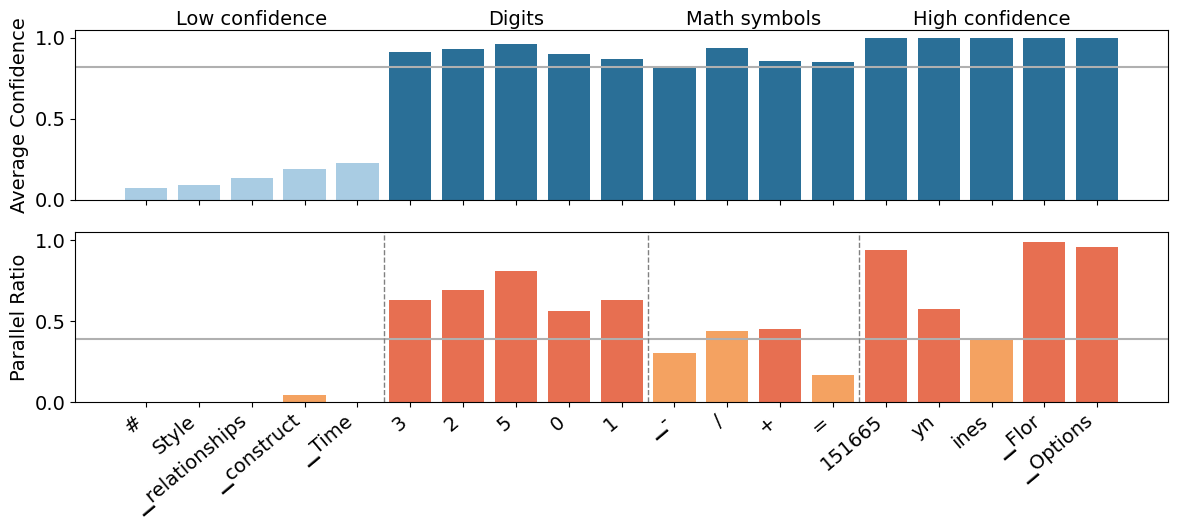

[DONE] gsm8k_token_analysis_t09_v2/fig_final_token_analysis.pdf


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Config
# =========================
num_per_category = 5

# =========================
# Font (GLOBAL STYLE)
# =========================
plt.rcParams.update({
    "font.size": 14,
    "font.family": "DejaVu Sans",
})

# =========================
# Token utils
# =========================
def normalize_token_for_category(token_str):
    s = str(token_str)
    s = s.replace("Ġ", "").strip()
    return s


def pretty_token_str(token_str):
    s = str(token_str)
    s = s.replace("Ġ", "▁")
    return s[:16]


# =========================
# Colors
# =========================
BLUE = "#2A6F97"
BLUE_LIGHT = "#A9CCE3"
ORANGE = "#E76F51"
ORANGE_LIGHT = "#F4A261"
GRAY = "#B0B0B0"


# =========================
# selectors (unchanged)
# =========================
def pick_low_confidence_tokens(stats, k=5, used_ids=None):
    used_ids = used_ids or set()
    df = stats[~stats["token_id"].isin(used_ids)].copy()
    df = df.sort_values("mean_confidence", ascending=True).head(k)
    df["category"] = "Low confidence"
    return df


def pick_high_confidence_tokens(stats, k=5, used_ids=None):
    used_ids = used_ids or set()
    df = stats[~stats["token_id"].isin(used_ids)].copy()
    df = df.sort_values("mean_confidence", ascending=False).head(k)
    df["category"] = "High confidence"
    return df


def pick_digit_tokens(stats, k=5, used_ids=None):
    used_ids = used_ids or set()
    digit_set = {str(i) for i in range(10)}

    rows = []
    for _, r in stats.iterrows():
        if r["token_id"] in used_ids:
            continue
        if normalize_token_for_category(r["token_str"]) in digit_set:
            rows.append(r)

    if not rows:
        return pd.DataFrame(columns=list(stats.columns) + ["category"])

    df = pd.DataFrame(rows).sort_values("freq", ascending=False).head(k)
    df["category"] = "Digits"
    return df


def pick_math_tokens(stats, k=5, used_ids=None):
    used_ids = used_ids or set()
    math_set = {"+", "-", "*", "/", "="}

    rows = []
    for _, r in stats.iterrows():
        if r["token_id"] in used_ids:
            continue
        if normalize_token_for_category(r["token_str"]) in math_set:
            rows.append(r)

    if not rows:
        return pd.DataFrame(columns=list(stats.columns) + ["category"])

    df = pd.DataFrame(rows).sort_values("freq", ascending=False).head(k)
    df["category"] = "Math symbols"
    return df


# =========================
# build
# =========================
def build_grouped(stats_by_freq, stats_by_conf, k=5):
    used = set()
    parts = []

    low = pick_low_confidence_tokens(stats_by_conf, k, used)
    parts.append(low); used.update(low["token_id"])

    dig = pick_digit_tokens(stats_by_freq, k, used)
    parts.append(dig); used.update(dig["token_id"])

    math = pick_math_tokens(stats_by_freq, k, used)
    parts.append(math); used.update(math["token_id"])

    high = pick_high_confidence_tokens(stats_by_conf, k, used)
    parts.append(high)

    df = pd.concat(parts, ignore_index=True)

    order = ["Low confidence", "Digits", "Math symbols", "High confidence"]
    df["category"] = pd.Categorical(df["category"], categories=order, ordered=True)
    df = df.sort_values("category").reset_index(drop=True)

    df["label"] = df.apply(lambda r: pretty_token_str(r["token_str"]), axis=1)

    return df


# =========================
# FINAL PLOT
# =========================
def plot_final(df, out_path, mean_conf, mean_par):
    x = np.arange(len(df))

    conf_colors = [
        BLUE if v >= df["mean_confidence"].mean() else BLUE_LIGHT
        for v in df["mean_confidence"]
    ]

    par_colors = [
        ORANGE if v >= df["parallel_ratio"].mean() else ORANGE_LIGHT
        for v in df["parallel_ratio"]
    ]

    fig, axes = plt.subplots(
        2, 1,
        figsize=(12, 5.5),
        sharex=True
    )

    # =========================
    # TOP
    # =========================
    axes[0].bar(x, df["mean_confidence"], color=conf_colors)
    axes[0].set_ylabel("Average Confidence", fontsize=14)
    axes[0].set_ylim(0, 1.05)
    axes[0].axhline(mean_conf, color=GRAY, linewidth=1.5)

    axes[0].tick_params(axis='both', labelsize=14)

    # =========================
    # BOTTOM
    # =========================
    axes[1].bar(x, df["parallel_ratio"], color=par_colors)
    axes[1].set_ylabel("Parallel Ratio", fontsize=14)
    axes[1].set_ylim(0, 1.05)
    axes[1].axhline(mean_par, color=GRAY, linewidth=1.5)

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(df["label"], rotation=40, ha="right", fontsize=14)

    axes[1].tick_params(axis='both', labelsize=14)

    # =========================
    # separators
    # =========================
    cats = df["category"].astype(str).tolist()
    prev = cats[0]
    for i, c in enumerate(cats):
        if c != prev:
            axes[1].axvline(i - 0.5, linestyle="--", color="gray", linewidth=1)
            prev = c

    # =========================
    # group labels (TOP)
    # =========================
    groups = {}
    for i, c in enumerate(df["category"]):
        groups.setdefault(str(c), []).append(i)

    for name, idxs in groups.items():
        mid = (idxs[0] + idxs[-1]) / 2
        axes[0].text(mid, 1.08, name, ha="center", fontsize=14)

    plt.tight_layout()
    
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


# =========================
# RUN
# =========================
grouped = build_grouped(stats_by_freq, stats_by_conf, num_per_category)

mean_conf = stats_by_freq["mean_confidence"].mean()
mean_par = stats_by_freq["parallel_ratio"].mean()

out_file = out_dir / "fig_final_token_analysis.pdf"

plot_final(grouped, out_file, mean_conf, mean_par)

grouped.to_csv(out_dir / "grouped_tokens.csv", index=False)

print("[DONE]", out_file)

基于p25的阈值统计（淘汰版方法）

In [5]:
from pathlib import Path
import json
import pandas as pd


# =========================
# 你只需要改这里
# =========================

# 可以是单个 log，也可以是多个 log
log_files = [
    "/Users/mc03002/Documents/soar_exp/data/gsm8k-len256_ns4_adaptive_parallel.log",
    # "/path/to/another.log",
]

out_dir = "token_threshold_stats"

# 低频 token 是否过滤
min_count = 20

# 是否对 threshold 做上下界截断
clip_threshold = True
tau_min = 0.0
tau_max = 1.0

# =========================


def load_records_from_logs(log_files):
    """
    Load decoding records from multiple log files.

    Requires these helper functions to be already defined:
    - parse_json_arrays_from_text
    - collect_records

    Each parsed record should contain:
    - token_id
    - confidence
    """
    all_records = []

    for log_file in log_files:
        log_path = Path(log_file)
        print(f"[INFO] Reading {log_path}")

        text = log_path.read_text(encoding="utf-8", errors="ignore")

        arrays = parse_json_arrays_from_text(text)
        print(f"  Parsed {len(arrays)} JSON-like trajectory arrays.")

        records = collect_records(arrays)
        print(f"  Collected {len(records)} token decoding records.")

        all_records.extend(records)

    print(f"[INFO] Total records: {len(all_records)}")
    return all_records


def build_token_quantile_thresholds(records, min_count=1, clip_threshold=True, tau_min=0.0, tau_max=1.0):
    """
    Compute p25, p50, p75 thresholds for each token_id.

    Returns:
    - stats_df
    - threshold_dicts:
        {
          "p25": {token_id: threshold},
          "p50": {token_id: threshold},
          "p75": {token_id: threshold},
          "mean": {token_id: threshold},
        }
    """
    df = pd.DataFrame(records)

    if df.empty:
        raise ValueError("No records found.")

    if "token_id" not in df.columns or "confidence" not in df.columns:
        raise ValueError("records must contain token_id and confidence fields.")

    df = df[["token_id", "confidence"]].copy()
    df["token_id"] = df["token_id"].astype(int)
    df["confidence"] = df["confidence"].astype(float)

    grouped = df.groupby("token_id")["confidence"]

    stats_df = grouped.agg(
        count="count",
        mean="mean",
        p05=lambda x: x.quantile(0.05),
        p10=lambda x: x.quantile(0.10),
        p15=lambda x: x.quantile(0.15),
        p25=lambda x: x.quantile(0.25),
        p50=lambda x: x.quantile(0.50),
        p75=lambda x: x.quantile(0.75),
        min_conf="min",
        max_conf="max",
    ).reset_index()

    # filter low-frequency tokens
    stats_df = stats_df[stats_df["count"] >= min_count].copy()

    if clip_threshold:
        for col in ["mean", "p05", "p10", "p15", "p25", "p50", "p75"]:
            stats_df[col] = stats_df[col].clip(lower=tau_min, upper=tau_max)

    threshold_dicts = {}

    for col in ["p05", "p10", "p15", "p25", "p50", "p75", "mean"]:
        threshold_dicts[col] = {
            str(int(row["token_id"])): float(row[col])
            for _, row in stats_df.iterrows()
        }

    return stats_df, threshold_dicts


def save_threshold_jsons(threshold_dicts, out_dir):
    """
    Save multiple JSON threshold files.
    Each file format:
      {token_id: threshold}
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for name, threshold_dict in threshold_dicts.items():
        out_path = out_dir / f"token_threshold_{name}.json"
        with out_path.open("w", encoding="utf-8") as f:
            json.dump(threshold_dict, f, indent=2, ensure_ascii=False)

        print(f"[SAVED] {out_path}")


# =========================
# Run
# =========================

out_dir = Path(out_dir)
out_dir.mkdir(parents=True, exist_ok=True)

records = load_records_from_logs(log_files)

stats_df, threshold_dicts = build_token_quantile_thresholds(
    records,
    min_count=min_count,
    clip_threshold=clip_threshold,
    tau_min=tau_min,
    tau_max=tau_max,
)

# Save full CSV for inspection
stats_csv_path = out_dir / "token_confidence_quantile_stats.csv"
stats_df.sort_values("count", ascending=False).to_csv(stats_csv_path, index=False)
print(f"[SAVED] {stats_csv_path}")

# Save JSON threshold files
save_threshold_jsons(threshold_dicts, out_dir)

display(stats_df.sort_values("count", ascending=False).head(20))

[INFO] Reading /Users/mc03002/Documents/soar_exp/data/gsm8k-len256_ns4_adaptive_parallel.log
  Parsed 1319 JSON-like trajectory arrays.
  Collected 337664 token decoding records.
[INFO] Total records: 337664
[SAVED] token_threshold_stats/token_confidence_quantile_stats.csv
[SAVED] token_threshold_stats/token_threshold_p05.json
[SAVED] token_threshold_stats/token_threshold_p10.json
[SAVED] token_threshold_stats/token_threshold_p15.json
[SAVED] token_threshold_stats/token_threshold_p25.json
[SAVED] token_threshold_stats/token_threshold_p50.json
[SAVED] token_threshold_stats/token_threshold_p75.json
[SAVED] token_threshold_stats/token_threshold_mean.json


,token_id,count,mean,p05,p10,p15,p25,p50,p75,min_conf,max_conf
79,220,21796,0.875908,0.363281,0.527344,0.656250,0.835938,1.000000,1.000000,0.080566,1.0
99,279,15779,0.701790,0.182617,0.259766,0.287109,0.451172,0.792969,1.000000,0.059326,1.0
13,13,14083,0.770909,0.183594,0.361328,0.439453,0.574219,0.910156,1.000000,0.083496,1.0
15,15,14081,0.899338,0.470703,0.625000,0.734375,0.878906,1.000000,1.000000,0.096191,1.0
85,264,11422,0.699350,0.227539,0.241211,0.306641,0.349609,0.761719,1.000000,0.122559,1.0
16,16,11415,0.870388,0.300781,0.423828,0.609766,0.867188,1.000000,1.000000,0.019287,1.0
126,315,11034,0.751253,0.265625,0.289062,0.304688,0.429688,0.906250,1.000000,0.072754,1.0
17,17,9938,0.931235,0.578125,0.667969,0.835938,0.968750,1.000000,1.000000,0.075684,1.0
18,18,7352,0.909179,0.554688,0.636719,0.730469,0.875000,1.000000,1.000000,0.079590,1.0
131,323,7240,0.864377,0.259766,0.480469,0.652344,0.816406,1.000000,1.000000,0.081543,1.0


样本的置信度直方图+与最终结果的对比

[INFO] Found problem_index=1 at line 252
[INFO] #selected_records = 253
[INFO] #all_token_records = 4131
[INFO] #final positions = 253
[INFO] global_step min/max = 1 256
[SAVED] figures/sample_confidence/confidence_by_position_problem1.png


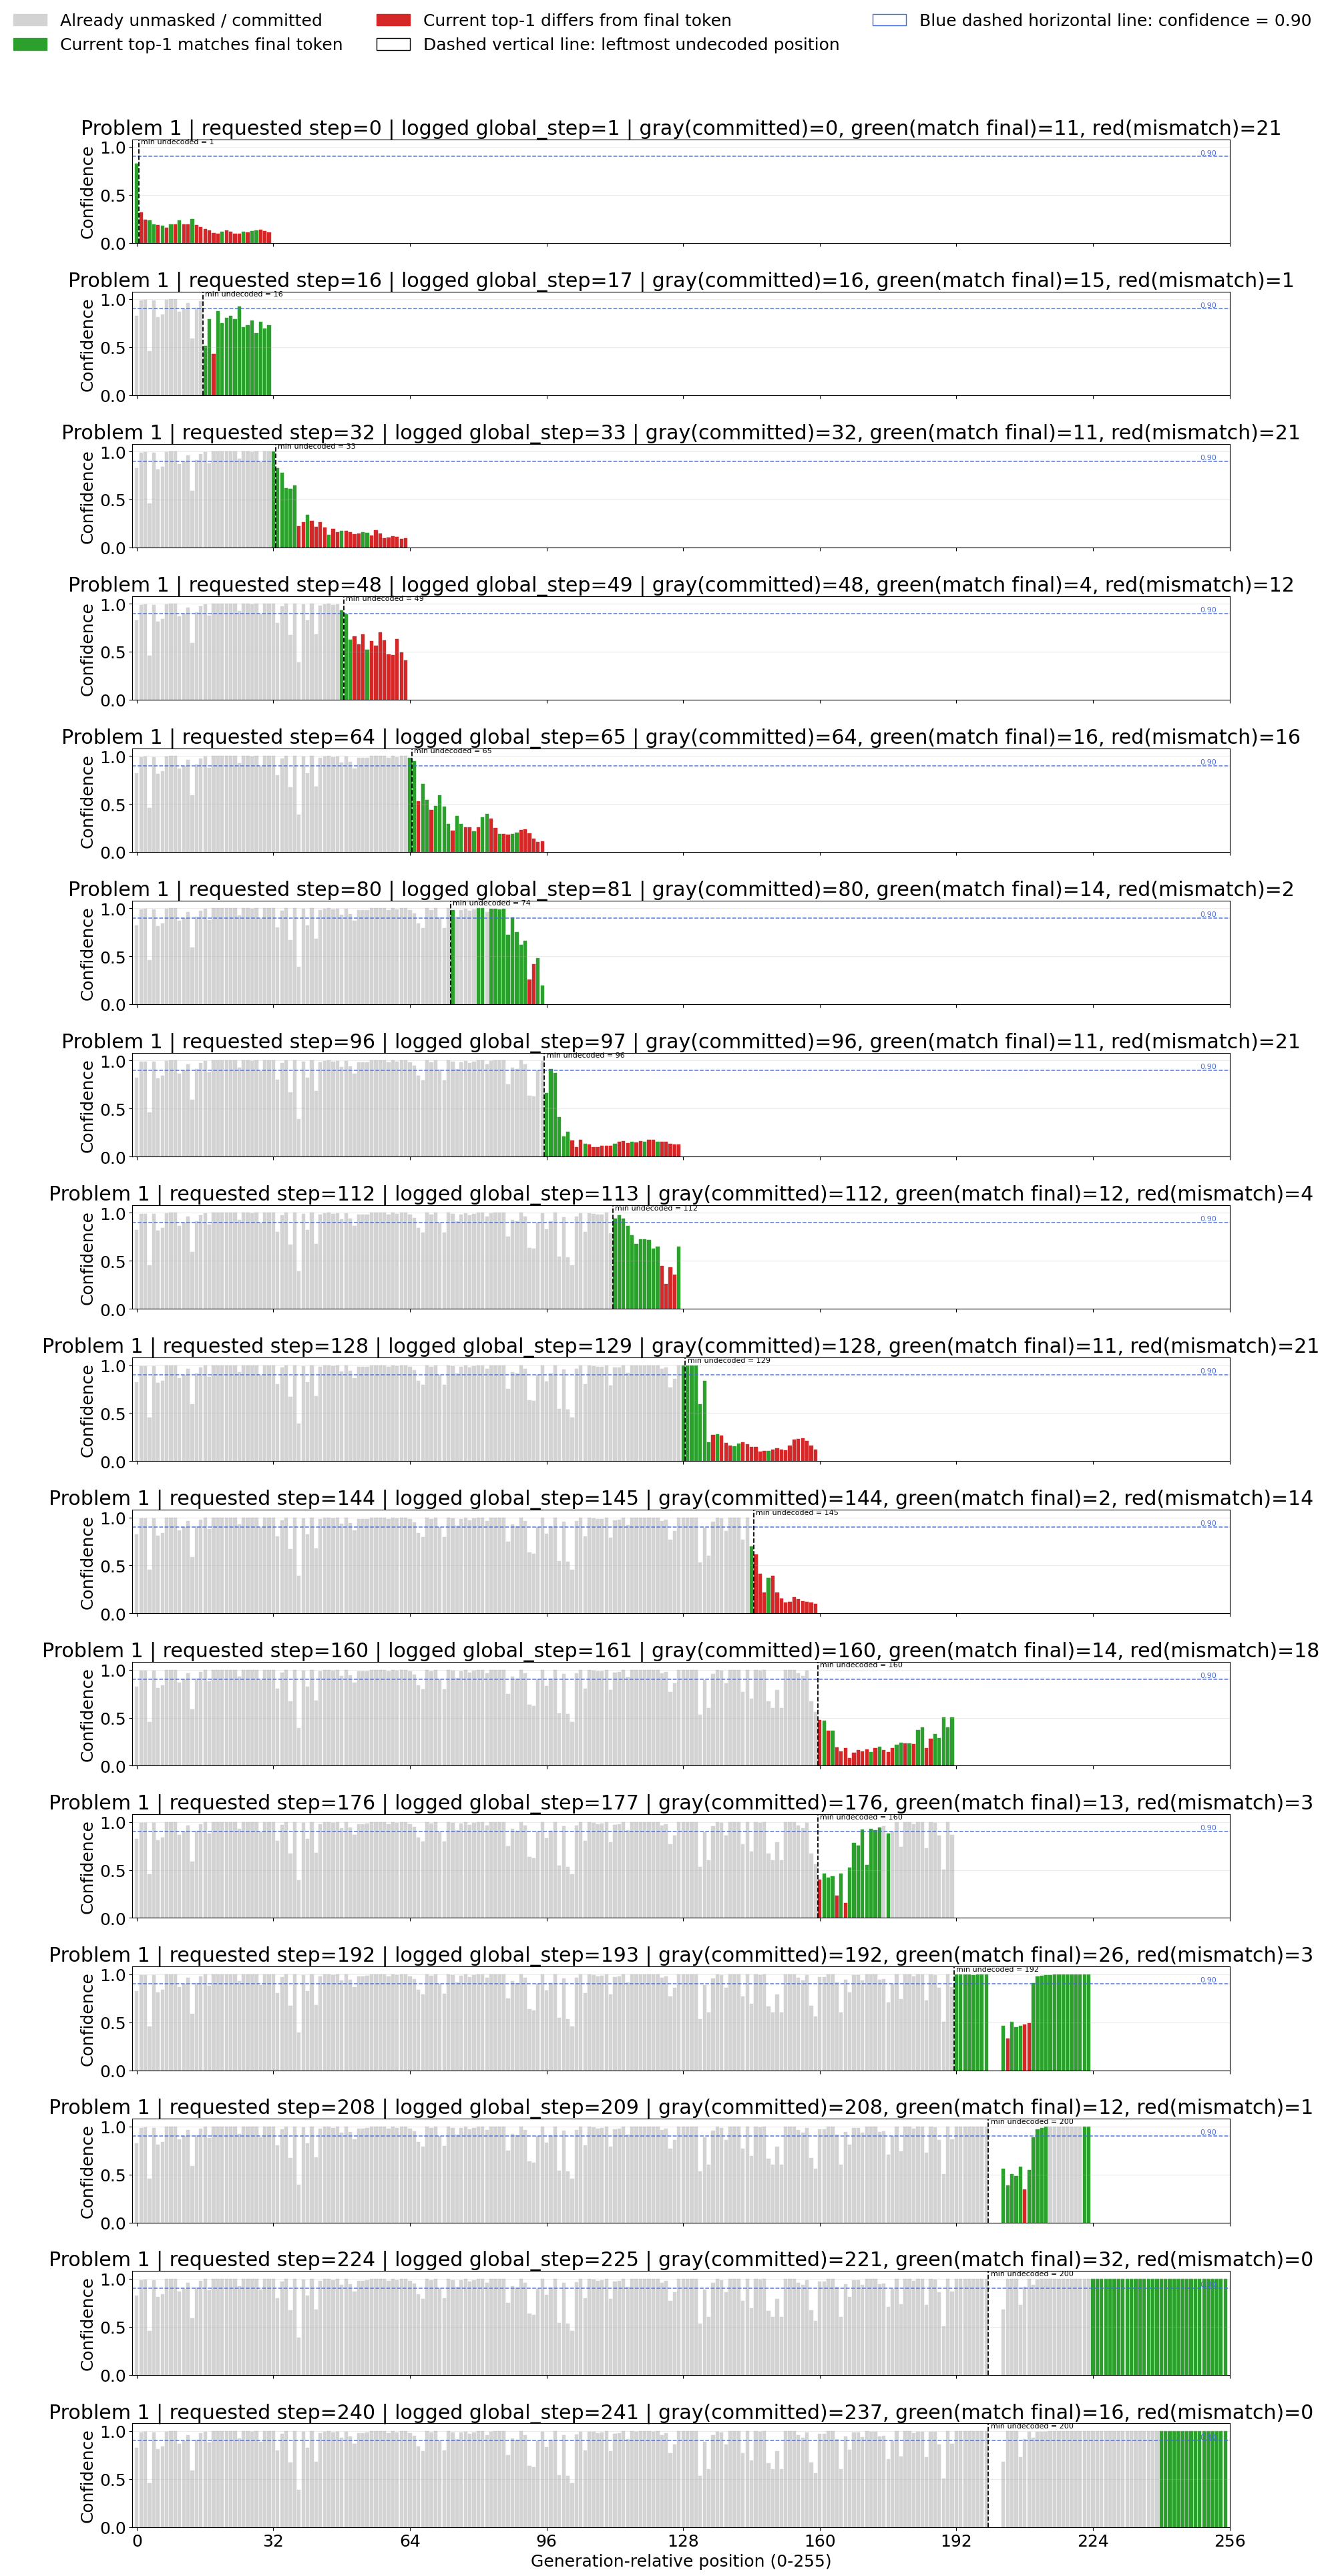

In [12]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def try_parse_json_object_from_line(line: str):
    """
    Try to parse a JSON object from a log line.

    Expected object format:
    {
        "selected_records": [...],
        "all_token_records": [...],
        "stats": {...}
    }
    """
    if '"all_token_records"' not in line:
        return None

    start = line.find("{")
    if start < 0:
        return None

    decoder = json.JSONDecoder()
    try:
        obj, end = decoder.raw_decode(line[start:])
        if isinstance(obj, dict) and "all_token_records" in obj and "selected_records" in obj:
            return obj
    except Exception:
        return None

    return None


def load_one_problem_trace(log_path, problem_index=0):
    """
    Stream the huge log file line by line.
    Return the problem_index-th JSON object that contains all_token_records.
    """
    log_path = Path(log_path)
    count = 0

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line_no, line in enumerate(f, start=1):
            obj = try_parse_json_object_from_line(line)
            if obj is None:
                continue

            if count == problem_index:
                print(f"[INFO] Found problem_index={problem_index} at line {line_no}")
                return obj

            count += 1

    raise ValueError(
        f"Could not find problem_index={problem_index}. "
        f"Only found {count} traces with all_token_records."
    )


def prepare_data(trace_obj):
    """
    Prepare:
    - df_all: dataframe from all_token_records
    - final_token_by_pos: final committed token for each generation position
    - commit_step_by_pos: the step when each generation position was committed
    - commit_conf_by_pos: confidence at commit step
    """
    selected_records = trace_obj["selected_records"]
    all_token_records = trace_obj["all_token_records"]

    df_all = pd.DataFrame(all_token_records)
    if df_all.empty:
        raise ValueError("all_token_records is empty.")

    # normalize dtypes
    for col in ["global_step", "local_step", "block", "position",
                "block_relative_position", "generation_relative_position", "token_id"]:
        if col in df_all.columns:
            df_all[col] = df_all[col].astype(int)

    df_all["confidence"] = df_all["confidence"].astype(float)

    # final token / commit step / commit confidence by generation position
    final_token_by_pos = {}
    commit_step_by_pos = {}
    commit_conf_by_pos = {}

    for r in selected_records:
        gen_pos = int(r["generation_relative_position"])
        final_token_by_pos[gen_pos] = int(r["token_id"])
        commit_step_by_pos[gen_pos] = int(r["global_step"])
        commit_conf_by_pos[gen_pos] = float(r["confidence"])

    # attach final token to df_all
    df_all["final_token_id"] = df_all["generation_relative_position"].map(final_token_by_pos)
    df_all["is_final_consistent"] = (
        df_all["final_token_id"].notna()
        & (df_all["token_id"] == df_all["final_token_id"].astype("Int64"))
    )

    return df_all, final_token_by_pos, commit_step_by_pos, commit_conf_by_pos


def map_requested_step_to_logged_step(step, zero_based=True):
    """
    Our logger uses global_step starting from 1.
    If zero_based=True:
        requested 0 -> logged 1
        requested 8 -> logged 9
    """
    return step + 1 if zero_based else step


def plot_confidence_for_one_problem(
    df_all,
    final_token_by_pos,
    commit_step_by_pos,
    commit_conf_by_pos,
    steps_to_plot,
    gen_length=256,
    zero_based_step_input=True,
    out_png=None,
    bar_width=0.82,
):
    """
    Plot full 0..255 positions for each requested step.

    Colors:
    - gray: already unmasked / committed before or at this step
    - green: current step record exists and current top-1 token == final token
    - red: current step record exists and current top-1 token != final token

    Notes:
    - Because the current logging only stores candidate confidences for the current block,
      only the current active block will have green/red bars.
    - Already committed positions are shown in gray using their commit confidence.
    - Future positions not yet active and not yet committed remain 0-height bars, but
      the x-axis still spans the full 0..255 range.
    """
    mapped_steps = [map_requested_step_to_logged_step(s, zero_based_step_input) for s in steps_to_plot]

    n = len(steps_to_plot)
    fig, axes = plt.subplots(
        n,
        1,
        figsize=(18, max(3, 2.4 * n)),
        sharex=True,
    )

    if n == 1:
        axes = [axes]

    all_positions = np.arange(gen_length)

    for ax, req_step, logged_step in zip(axes, steps_to_plot, mapped_steps):

        # initialize full arrays
        heights = np.zeros(gen_length, dtype=float)
        colors = np.array(["white"] * gen_length, dtype=object)  # default blank
        edgecolors = np.array(["white"] * gen_length, dtype=object)

        # 1) already committed positions -> gray
        for pos in range(gen_length):
            commit_step = commit_step_by_pos.get(pos, None)
            if commit_step is not None and commit_step <= logged_step:
                heights[pos] = commit_conf_by_pos.get(pos, 1.0)
                colors[pos] = "lightgray"
                edgecolors[pos] = "lightgray"

        # 2) current step active positions -> override with red/green + current confidence
        sub = df_all[df_all["global_step"] == logged_step].copy()
        sub = sub.sort_values("generation_relative_position")

        for _, row in sub.iterrows():
            pos = int(row["generation_relative_position"])
            if pos < 0 or pos >= gen_length:
                continue

            heights[pos] = float(row["confidence"])
            if bool(row["is_final_consistent"]):
                colors[pos] = "tab:green"
                edgecolors[pos] = "tab:green"
            else:
                colors[pos] = "tab:red"
                edgecolors[pos] = "tab:red"

        # 3) find the left boundary: the minimum position among currently undecoded tokens
        undecoded_positions = []
        for pos in range(gen_length):
            commit_step = commit_step_by_pos.get(pos, None)
            if commit_step is None or commit_step > logged_step:
                undecoded_positions.append(pos)

        min_undecoded_pos = min(undecoded_positions) if len(undecoded_positions) > 0 else None

        # draw bars
        ax.bar(
            all_positions,
            heights,
            width=bar_width,
            color=colors.tolist(),
            edgecolor=edgecolors.tolist(),
            linewidth=0.3,
        )

        # horizontal reference line at 0.90
        ax.axhline(0.90, color="royalblue", linestyle="--", linewidth=1.1, alpha=0.9)
        ax.text(
            gen_length - 3,
            0.905,
            "0.90",
            color="royalblue",
            fontsize=8,
            ha="right",
            va="bottom",
        )

        # vertical divider at left of the minimum undecoded position
        if min_undecoded_pos is not None:
            ax.axvline(
                min_undecoded_pos - 0.5,
                color="black",
                linestyle="--",
                linewidth=1.3,
            )
            ax.text(
                min_undecoded_pos,
                1.02,
                f"min undecoded = {min_undecoded_pos}",
                fontsize=8,
                ha="left",
                va="bottom",
                color="black",
            )

        # stats for title
        num_gray = np.sum(colors == "lightgray")
        num_green = np.sum(colors == "tab:green")
        num_red = np.sum(colors == "tab:red")

        ax.set_xlim(-1, gen_length)
        ax.set_ylim(0, 1.08)
        ax.set_ylabel("Confidence")
        ax.set_title(
            f"Problem {problem_index} | requested step={req_step} | logged global_step={logged_step} | "
            f"gray(committed)={num_gray}, green(match final)={num_green}, red(mismatch)={num_red}"
        )
        ax.grid(axis="y", alpha=0.25)

    axes[-1].set_xlabel("Generation-relative position (0-255)")
    axes[-1].set_xticks(list(range(0, gen_length + 1, 32)))

    legend_handles = [
        Patch(color="lightgray", label="Already unmasked / committed"),
        Patch(color="tab:green", label="Current top-1 matches final token"),
        Patch(color="tab:red", label="Current top-1 differs from final token"),
        Patch(facecolor="white", edgecolor="black", label="Dashed vertical line: leftmost undecoded position"),
        Patch(facecolor="white", edgecolor="royalblue", label="Blue dashed horizontal line: confidence = 0.90"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.01),
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    if out_png is not None:
        out_path = Path(out_png)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"[SAVED] {out_path}")

    plt.show()

# =========================
# User config
# =========================
log_file = "/Users/mc03002/Documents/Prophet/logs/baseline-gsm8k_standard-len256-block32-4gpu.log"

# 第几个问题，0-based index
problem_index = 1

# 你想看的 decoding steps
# 如果 ZERO_BASED_STEP_INPUT=True，那么 step=0 会映射到日志里的 global_step=1
steps_to_plot = list(range(0, 256, 16))

ZERO_BASED_STEP_INPUT = True

out_png = f"figures/sample_confidence/confidence_by_position_problem{problem_index}.png"

gen_length = 256
prompt_len = None   # 可不填，这里用 generation_relative_position 即可
bar_width = 0.82
# =========================

# =========================
# Run
# =========================
trace_obj = load_one_problem_trace(log_file, problem_index=problem_index)

df_all, final_token_by_pos, commit_step_by_pos, commit_conf_by_pos = prepare_data(trace_obj)

print("[INFO] #selected_records =", len(trace_obj["selected_records"]))
print("[INFO] #all_token_records =", len(trace_obj["all_token_records"]))
print("[INFO] #final positions =", len(final_token_by_pos))
print("[INFO] global_step min/max =", df_all["global_step"].min(), df_all["global_step"].max())

plot_confidence_for_one_problem(
    df_all=df_all,
    final_token_by_pos=final_token_by_pos,
    commit_step_by_pos=commit_step_by_pos,
    commit_conf_by_pos=commit_conf_by_pos,
    steps_to_plot=steps_to_plot,
    gen_length=gen_length,
    zero_based_step_input=ZERO_BASED_STEP_INPUT,
    out_png=out_png,
    bar_width=bar_width,
)

[INFO] Found problem_index=1 at line 252


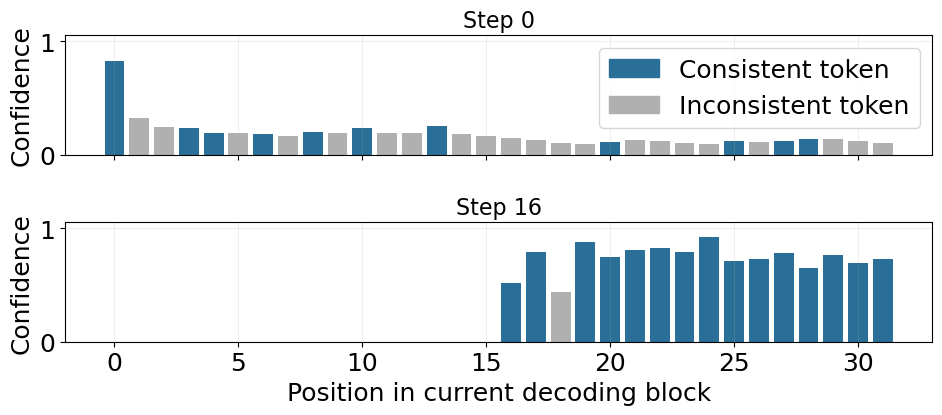

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# =========================
# Config
# =========================
problem_index = 1
block_id = 0
block_size = 32
gen_length = 256


# =========================
# Colors
# =========================
BLUE = "#2A6F97"
GRAY = "#B0B0B0"


# =========================
# Load trace
# =========================
trace = load_one_problem_trace(log_file, problem_index)
df_all, final_token_by_pos, commit_step_by_pos, commit_conf_by_pos = prepare_data(trace)


# =========================
# Block range
# =========================
start = block_id * block_size
end = start + block_size
positions = np.arange(start, end)


# =========================
# snapshot
# =========================
def get_step_snapshot(step_id):
    step = step_id + 1

    sub = df_all[df_all["global_step"] == step].copy()
    sub = sub.set_index("generation_relative_position")

    conf = np.zeros(gen_length)
    color = [GRAY] * gen_length

    for pos in range(start, end):

        if pos in sub.index:
            row = sub.loc[pos]
            conf[pos] = row["confidence"]

            if row["token_id"] == final_token_by_pos.get(pos, -1):
                color[pos] = BLUE
            else:
                color[pos] = GRAY

    return conf, color


# =========================
# snapshots
# =========================
conf0, col0 = get_step_snapshot(0)
confH, colH = get_step_snapshot(block_size // 2)


# =========================
# plot
# =========================
fig, axes = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True)

axes[0].bar(positions, conf0[start:end], color=[col0[p] for p in positions])
axes[1].bar(positions, confH[start:end], color=[colH[p] for p in positions])


# =========================
# ADDED TITLES
# =========================
axes[0].set_title("Step 0", fontsize=16)
axes[1].set_title("Step 16", fontsize=16)


for ax in axes:
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Confidence", fontsize=18)
    ax.grid(alpha=0.2)

axes[1].set_xlabel("Position in current decoding block", fontsize=18)


# =========================
# legend
# =========================
legend_items = [
    Patch(color=BLUE, label="Consistent token"),
    Patch(color=GRAY, label="Inconsistent token"),
]

axes[0].legend(
    handles=legend_items,
    loc="upper right",
    frameon=True,
    fontsize=18,
)

plt.tight_layout()

# =========================
# SAVE PDF
# =========================
out_dir = Path("figures/block_decoding_visualization")
out_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    out_dir / "block_decoding_visualization.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from pathlib import Path


# =========================
# Config
# =========================
fixed_log_file = "logs/gsm8k_adaptive_parallel_len256_block32_thr0.90.log"
cal_log_file = "logs/gsm8k_dynamic_from_global_v2_c99.5_mincount200_minaccepted100_len256_block32_maxthr0.90_minthr0.05.log"

problem_index = 0
block_id = 0
block_size = 32

out_dir = Path("figures/decoding_path")
out_name = "decoding_path_grid.pdf"


# =========================
# Style
# =========================
plt.rcParams.update({
    "font.size": 18,
    "font.family": "DejaVu Sans",
})

BLUE = "#2A6F97"
BLUE_DARK = "#083D5D"

ORANGE = "#E76F51"
ORANGE_DARK = "#9C2F1A"

WHITE = "#FFFFFF"
GRID = "#D0D0D0"


# =========================
# Helper
# =========================
def build_decoding_grid(log_file, problem_index, block_id, block_size):
    """
    Return:
        grid: [num_steps, block_size]
              0 = not committed at this step
              1 = committed at this step
              2 = singleton-step commit, i.e., only one token committed in this step
        local_steps: step ids starting from 0
        positions_in_block: 0 ... block_size-1
    """

    trace = load_one_problem_trace(log_file, problem_index)
    df_all, final_token_by_pos, commit_step_by_pos, commit_conf_by_pos = prepare_data(trace)

    start = block_id * block_size
    end = start + block_size
    block_positions = list(range(start, end))

    # Only keep positions inside this block
    commit_items = []
    for pos in block_positions:
        if pos in commit_step_by_pos:
            step = commit_step_by_pos[pos]
            if step is not None:
                commit_items.append((pos, int(step)))

    if len(commit_items) == 0:
        raise ValueError(f"No committed tokens found for block_id={block_id} in {log_file}")

    # Normalize global step to local step within this block
    min_step = min(s for _, s in commit_items)
    max_step = max(s for _, s in commit_items)

    num_steps = max_step - min_step + 1
    grid = np.zeros((num_steps, block_size), dtype=int)

    # Count how many tokens are committed at each step
    step_to_positions = {}
    for pos, step in commit_items:
        local_step = step - min_step
        local_pos = pos - start
        step_to_positions.setdefault(local_step, []).append(local_pos)

    for local_step, local_positions in step_to_positions.items():
        if len(local_positions) == 1:
            grid[local_step, local_positions[0]] = 2
        else:
            for lp in local_positions:
                grid[local_step, lp] = 1

    local_steps = np.arange(num_steps)
    positions_in_block = np.arange(block_size)

    return grid, local_steps, positions_in_block


def plot_one_grid(ax, grid, title, main_color, dark_color):
    cmap = ListedColormap([WHITE, main_color, dark_color])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

    ax.imshow(
        grid,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        norm=norm,
        origin="upper",
    )

    num_steps, block_size = grid.shape

    # Grid lines
    ax.set_xticks(np.arange(-0.5, block_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, num_steps, 1), minor=True)
    ax.grid(which="minor", color=GRID, linewidth=0.35)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Ticks
    ax.set_xticks(np.arange(0, block_size, 4))
    ax.set_xticklabels(np.arange(0, block_size, 4))

    if num_steps <= 20:
        yticks = np.arange(num_steps)
    else:
        yticks = np.linspace(0, num_steps - 1, 6).astype(int)

    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks)

    ax.set_ylabel("Decoding step")
    ax.set_title(title, fontsize=18)

    # Highlight singleton steps with black outline
    singleton_rows, singleton_cols = np.where(grid == 2)
    ax.scatter(
        singleton_cols,
        singleton_rows,
        s=95,
        facecolors="none",
        edgecolors="black",
        linewidths=1.6,
        zorder=5,
    )


# =========================
# Build grids
# =========================
fixed_grid, fixed_steps, positions = build_decoding_grid(
    fixed_log_file,
    problem_index,
    block_id,
    block_size,
)

cal_grid, cal_steps, positions = build_decoding_grid(
    cal_log_file,
    problem_index,
    block_id,
    block_size,
)

# Pad to same number of steps for aligned comparison
max_steps = max(fixed_grid.shape[0], cal_grid.shape[0])

def pad_grid(grid, max_steps):
    if grid.shape[0] == max_steps:
        return grid
    pad = np.zeros((max_steps - grid.shape[0], grid.shape[1]), dtype=int)
    return np.vstack([grid, pad])

fixed_grid = pad_grid(fixed_grid, max_steps)
cal_grid = pad_grid(cal_grid, max_steps)


# =========================
# Plot: two rows, one column
# =========================
fig, axes = plt.subplots(
    2, 1,
    figsize=(11, 6.5),
    sharex=True,
    sharey=True,
)

plot_one_grid(
    axes[0],
    fixed_grid,
    "Fixed-threshold APD",
    BLUE,
    BLUE_DARK,
)

plot_one_grid(
    axes[1],
    cal_grid,
    "Calibrated-threshold APD",
    ORANGE,
    ORANGE_DARK,
)

axes[1].set_xlabel("Position in current decoding block")

# Legend
legend_items = [
    Patch(facecolor=BLUE, edgecolor="none", label="Fixed: committed token"),
    Patch(facecolor=BLUE_DARK, edgecolor="black", label="Fixed: singleton step"),
    Patch(facecolor=ORANGE, edgecolor="none", label="Calibrated: committed token"),
    Patch(facecolor=ORANGE_DARK, edgecolor="black", label="Calibrated: singleton step"),
]

fig.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=True,
    fontsize=14,
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

# =========================
# Save
# =========================
out_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(out_dir / out_name, bbox_inches="tight", dpi=300)
plt.savefig(out_dir / out_name.replace(".pdf", ".png"), bbox_inches="tight", dpi=300)

plt.show()

ValueError: Could not find problem_index=0. Only found 0 traces with all_token_records.

更加细粒度的分析

In [23]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# Config
# =========================
log_file = "logs/baseline-gsm8k_train_standard-len256-block32.log"

# 读取多少个问题；None 表示全读，但大日志会很慢
max_problems = None

gen_length = 256
out_dir = Path("figures/final_consistency")
out_dir.mkdir(parents=True, exist_ok=True)

# confidence bins
bin_width = 0.1
bins = np.arange(0.0, 1.0 + bin_width, bin_width)

# 指定 token id
target_token_ids = [10, 18, 8752, 12032]
token_id_to_name = {
    10: "+",
    18: "3",
    8752: "Style",
    12032: "options",
}

# position bucket
num_pos_buckets = 8
# =========================


def try_parse_json_object_from_line(line: str):
    """
    Parse one JSON object containing:
      selected_records
      all_token_records
      stats
    """
    if '"all_token_records"' not in line:
        return None

    start = line.find("{")
    if start < 0:
        return None

    decoder = json.JSONDecoder()
    try:
        obj, _ = decoder.raw_decode(line[start:])
        if isinstance(obj, dict) and "all_token_records" in obj and "selected_records" in obj:
            return obj
    except Exception:
        return None

    return None


def iter_trace_objects(log_path, max_problems=None):
    """
    Stream huge log file line by line.
    """
    log_path = Path(log_path)
    count = 0

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line_no, line in enumerate(f, start=1):
            obj = try_parse_json_object_from_line(line)
            if obj is None:
                continue

            yield count, obj

            count += 1
            if max_problems is not None and count >= max_problems:
                break

    print(f"[INFO] Loaded {count} traces.")


def trace_to_dataframe(problem_idx, trace_obj):
    """
    Build dataframe with final-consistency labels.

    final_consistent = current top-1 token at this step equals final committed token at same position.
    """
    selected_records = trace_obj["selected_records"]
    all_token_records = trace_obj["all_token_records"]

    final_token_by_pos = {}
    commit_step_by_pos = {}

    for r in selected_records:
        gen_pos = int(r["generation_relative_position"])
        final_token_by_pos[gen_pos] = int(r["token_id"])
        commit_step_by_pos[gen_pos] = int(r["global_step"])

    df = pd.DataFrame(all_token_records)
    if df.empty:
        return df

    needed_cols = [
        "global_step",
        "block",
        "generation_relative_position",
        "confidence",
        "token_id",
    ]
    for col in needed_cols:
        if col not in df.columns:
            raise ValueError(f"Missing column {col} in all_token_records.")

    df["problem_idx"] = problem_idx
    df["global_step"] = df["global_step"].astype(int)
    df["block"] = df["block"].astype(int)
    df["generation_relative_position"] = df["generation_relative_position"].astype(int)
    df["confidence"] = df["confidence"].astype(float)
    df["token_id"] = df["token_id"].astype(int)

    df["final_token_id"] = df["generation_relative_position"].map(final_token_by_pos)
    df["commit_step"] = df["generation_relative_position"].map(commit_step_by_pos)

    df["final_consistent"] = (
        df["final_token_id"].notna()
        & (df["token_id"] == df["final_token_id"].astype("Int64"))
    )

    # 只保留正常 confidence
    df = df[np.isfinite(df["confidence"])].copy()
    df = df[(df["confidence"] >= 0.0) & (df["confidence"] <= 1.0)].copy()

    return df


def load_all_records(log_file, max_problems=None):
    dfs = []

    for problem_idx, obj in iter_trace_objects(log_file, max_problems=max_problems):
        df = trace_to_dataframe(problem_idx, obj)
        if not df.empty:
            dfs.append(df)

    if len(dfs) == 0:
        raise RuntimeError("No valid all_token_records found.")

    all_df = pd.concat(dfs, ignore_index=True)
    print(f"[INFO] Total candidate records: {len(all_df)}")
    print(f"[INFO] Problems: {all_df['problem_idx'].nunique()}")
    return all_df


def add_confidence_bins(df, bins):
    df = df.copy()
    df["conf_bin"] = pd.cut(
        df["confidence"],
        bins=bins,
        include_lowest=True,
        right=False,
    )
    df["conf_bin_mid"] = df["conf_bin"].apply(lambda x: (x.left + x.right) / 2 if pd.notna(x) else np.nan)
    df["conf_bin_label"] = df["conf_bin"].astype(str)
    return df


def compute_bin_stats(df, group_cols):
    """
    Compute final-consistency rate and count for bins/groups.
    """
    stats = (
        df.groupby(group_cols, observed=True)
        .agg(
            final_consistency_rate=("final_consistent", "mean"),
            count=("final_consistent", "size"),
            mean_confidence=("confidence", "mean"),
        )
        .reset_index()
    )
    return stats


# =========================
# Load and prepare data
# =========================
all_df = load_all_records(log_file, max_problems=max_problems)
all_df = add_confidence_bins(all_df, bins=bins)

[INFO] Loaded 7473 traces.
[INFO] Total candidate records: 31565952
[INFO] Problems: 7473


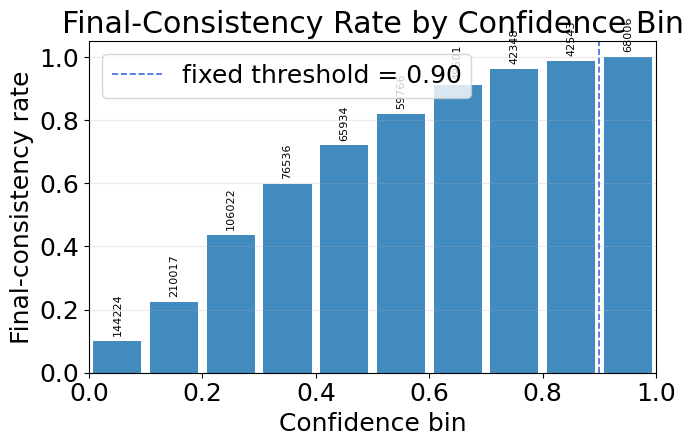

[SAVED] figures/final_consistency/fig1_overall_confidence_bin_final_consistency.png


,conf_bin,conf_bin_mid,final_consistency_rate,count,mean_confidence
0,"[0.0, 0.1)",0.05,0.100268,144224,0.076612
1,"[0.1, 0.2)",0.15,0.225482,210017,0.142733
2,"[0.2, 0.3)",0.25,0.435674,106022,0.245866
3,"[0.3, 0.4)",0.35,0.598751,76536,0.347745
4,"[0.4, 0.5)",0.45,0.72063,65934,0.448674
5,"[0.5, 0.6)",0.55,0.820517,59766,0.547903
6,"[0.6, 0.7)",0.65,0.911719,49501,0.649309
7,"[0.7, 0.8)",0.75,0.962383,42348,0.749616
8,"[0.8, 0.9)",0.85,0.988529,42543,0.849898
9,"[0.9, 1.0)",0.95,1.0,68006,0.963094


In [16]:
overall_stats = compute_bin_stats(all_df, ["conf_bin", "conf_bin_mid"])

overall_stats = overall_stats.sort_values("conf_bin_mid")

plt.figure(figsize=(7.2, 4.8))
plt.bar(
    overall_stats["conf_bin_mid"].astype(float),
    overall_stats["final_consistency_rate"],
    width=bin_width * 0.85,
    alpha=0.85,
)

for _, row in overall_stats.iterrows():
    x = float(row["conf_bin_mid"])
    y = float(row["final_consistency_rate"])
    c = int(row["count"])
    plt.text(x, y + 0.015, str(c), ha="center", va="bottom", fontsize=8, rotation=90)

plt.axvline(0.90, linestyle="--", linewidth=1.2, color="royalblue", label="fixed threshold = 0.90")
plt.ylim(0, 1.05)
plt.xlim(0, 1.0)
plt.xlabel("Confidence bin")
plt.ylabel("Final-consistency rate")
plt.title("Final-Consistency Rate by Confidence Bin")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()

out_path = out_dir / "fig1_overall_confidence_bin_final_consistency.png"
plt.savefig(out_path, dpi=300)
plt.show()

print(f"[SAVED] {out_path}")
display(overall_stats)

In [17]:
from pathlib import Path
import json
import pandas as pd


tokenizer_json_path = "/Users/mc03002/Documents/Prophet/gsm8k_token_analysis_t09/tokenizer.json"


def load_id_to_token(tokenizer_json_path):
    with open(tokenizer_json_path, "r", encoding="utf-8") as f:
        tok = json.load(f)

    id_to_token = {}

    vocab = tok.get("model", {}).get("vocab", {})
    for s, i in vocab.items():
        id_to_token[int(i)] = s

    for item in tok.get("added_tokens", []):
        if "id" in item and "content" in item:
            id_to_token[int(item["id"])] = item["content"]

    return id_to_token


def clean_token_str(s):
    s = str(s)
    s = s.replace("Ġ", "▁")
    s = s.replace("Ċ", "\\n")
    s = s.replace("\n", "\\n").replace("\t", "\\t")
    if s == " ":
        return "<space>"
    if s == "":
        return "<empty>"
    return s


def build_stats_from_all_df(all_df):
    """
    Build token-level statistics from all_token_records dataframe.
    Required columns:
      token_id, confidence
    """
    df = all_df.copy()
    df["token_id"] = df["token_id"].astype(int)
    df["confidence"] = df["confidence"].astype(float)

    stats = (
        df.groupby("token_id")
        .agg(
            freq=("token_id", "size"),
            mean_confidence=("confidence", "mean"),
            median_confidence=("confidence", "median"),
            p25_confidence=("confidence", lambda x: x.quantile(0.25)),
            p75_confidence=("confidence", lambda x: x.quantile(0.75)),
        )
        .reset_index()
    )

    return stats


def build_token_id_to_name(
    all_df,
    tokenizer_json_path,
    mode="digits",
    n=10,
    min_freq=1,
):
    """
    Build token_id_to_name from all_df directly.

    mode:
      - digits
      - math_symbols
      - top_freq
      - top_conf
      - low_conf
    """
    id_to_token = load_id_to_token(tokenizer_json_path)
    stats_df = build_stats_from_all_df(all_df)

    df = stats_df.copy()
    df = df[df["freq"] >= min_freq].copy()

    if mode == "digits":
        wanted = {str(i) for i in range(10)}
        selected = []

        # 只选 all_df 里出现过的 digit token
        existing_ids = set(df["token_id"].astype(int).tolist())

        for tid, tok in id_to_token.items():
            if tid not in existing_ids:
                continue
            norm = tok.replace("Ġ", "").strip()
            if norm in wanted:
                selected.append((tid, norm))

        selected = sorted(selected, key=lambda x: int(x[1]))
        return {tid: name for tid, name in selected}

    if mode == "math_symbols":
        symbols = {
            "+", "-", "*", "/", "=",
            ".", ",", ":", ";",
            "(", ")", "[", "]", "{", "}",
            "$", "%", "<", ">", "#"
        }

        selected = []
        existing_ids = set(df["token_id"].astype(int).tolist())

        for tid, tok in id_to_token.items():
            if tid not in existing_ids:
                continue
            norm = tok.replace("Ġ", "").strip()
            if norm in symbols:
                selected.append((tid, norm))

        order = ["+", "-", "*", "/", "=", "(", ")", "[", "]", "{", "}", "$", "%", "<", ">", ".", ",", ":", ";", "#"]
        order_map = {s: i for i, s in enumerate(order)}
        selected = sorted(selected, key=lambda x: order_map.get(x[1], 999))

        return {tid: name for tid, name in selected}

    if mode == "top_freq":
        sub = df.sort_values("freq", ascending=False).head(n)

    elif mode == "top_conf":
        sub = df.sort_values("mean_confidence", ascending=False).head(n)

    elif mode == "low_conf":
        sub = df.sort_values("mean_confidence", ascending=True).head(n)

    else:
        raise ValueError(f"Unknown mode: {mode}")

    token_id_to_name = {}
    for tid in sub["token_id"].tolist():
        tid = int(tid)
        token_id_to_name[tid] = clean_token_str(id_to_token.get(tid, f"<unk:{tid}>"))

    return token_id_to_name

min_freq = 500
digits_dict = build_token_id_to_name(
    all_df,
    tokenizer_json_path,
    mode="digits",
    n=10,
    min_freq=500,
)

math_symbols_dict = build_token_id_to_name(
    all_df,
    tokenizer_json_path,
    mode="math_symbols",
    n=10,
    min_freq=500,
)

top_freq_dict = build_token_id_to_name(
    all_df,
    tokenizer_json_path,
    mode="top_freq",
    n=10,
    min_freq=500,
)

top_conf_dict = build_token_id_to_name(
    all_df,
    tokenizer_json_path,
    mode="top_conf",
    n=10,
    min_freq=500,
)

low_conf_dict = build_token_id_to_name(
    all_df,
    tokenizer_json_path,
    mode="low_conf",
    n=10,
    min_freq=500,
)

print("digits:", digits_dict)
print("math symbols:", math_symbols_dict)
print("top freq:", top_freq_dict)
print("top conf:", top_conf_dict)
print("low conf:", low_conf_dict)

digits: {15: '0', 16: '1', 17: '2', 18: '3', 19: '4', 20: '5', 21: '6', 22: '7', 23: '8', 24: '9'}
math symbols: {10: '+', 781: '+', 12: '-', 537: '-', 28: '=', 373: '=', 7: '(', 363: '(', 8: ')', 60: ']', 90: '{', 92: '}', 3: '$', 558: '$', 797: '<', 13: '.', 11: ',', 25: ':'}
top freq: {198: '\\n', 220: '▁', 268: '▁the', 17: '2', 16: '1', 558: '▁$', 795: '▁\\', 126081: '<|endoftext|>', 15: '0', 11: ','}
top conf: {126081: '<|endoftext|>', 126348: '<unk:126348>', 11729: '\\]', 60: ']', 9622: 'times', 10702: 'cdot', 2157: '}}', 7684: '}.', 2335: 'text', 1669: '▁value'}
low conf: {59047: '(-\\', 5436: 'angle', 3126: 'aps', 558: '▁$', 67128: 'triangle', 268: '▁the', 12407: 'omega', 24946: '▁\\(', 9796: '▁prime', 1672: 'We'}


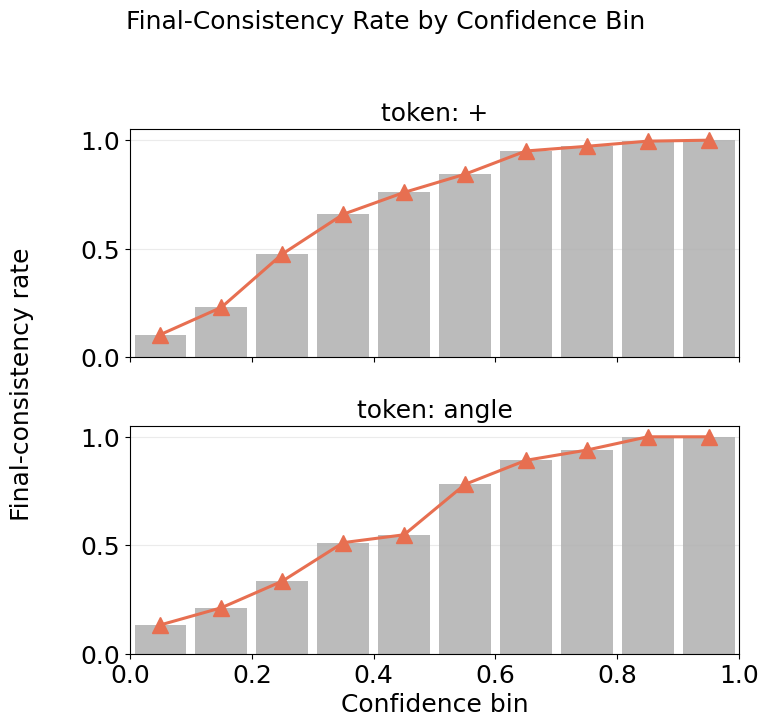

[SAVED] figures/final_consistency/fig_selected_tokens_hist_final_consistency.pdf


In [18]:
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# config
# =========================
out_dir = Path("figures/final_consistency")
out_dir.mkdir(parents=True, exist_ok=True)

bin_width = 0.1

# =========================
# colors
# =========================
GRAY = "#B0B0B0"
ORANGE = "#E76F51"

# =========================
# main function
# =========================
def plot_selected_tokens_final_consistency_hist(
    all_df,
    target_token_ids,
    token_id_to_name=None,
    bin_width=0.1,
    out_dir=Path("figures/final_consistency"),
    filename="fig_selected_tokens_hist_final_consistency.pdf",
):

    if token_id_to_name is None:
        token_id_to_name = {}

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    target_token_ids = list(target_token_ids)
    n_tokens = len(target_token_ids)

    if n_tokens == 0:
        raise ValueError("target_token_ids is empty.")

    # =========================
    # aggregate stats
    # =========================
    token_df = all_df[all_df["token_id"].isin(target_token_ids)].copy()

    token_stats = (
        token_df.groupby(
            ["token_id", "conf_bin", "conf_bin_mid"],
            observed=True
        )
        .agg(
            final_consistency_rate=("final_consistent", "mean"),
            count=("final_consistent", "size"),
        )
        .reset_index()
    )

    fig, axes = plt.subplots(
        n_tokens,
        1,
        figsize=(8, 3.6 * n_tokens),
        sharex=True,
        sharey=True,
    )

    if n_tokens == 1:
        axes = [axes]

    for ax, tid in zip(axes, target_token_ids):

        sub = token_stats[token_stats["token_id"] == tid].copy()
        sub = sub.sort_values("conf_bin_mid")

        token_name = token_id_to_name.get(tid, f"token_{tid}")
        ax.set_title(f"token: {token_name}", fontsize=18)

        if sub.empty:
            ax.text(
                0.5, 0.5, "No records",
                ha="center", va="center",
                transform=ax.transAxes,
                fontsize=18
            )
            continue

        x = sub["conf_bin_mid"].values
        y = sub["final_consistency_rate"].values

        ax.bar(
            x, y,
            width=bin_width * 0.85,
            color=GRAY,
            edgecolor="none",
            alpha=0.85,
        )

        ax.plot(
            x, y,
            color=ORANGE,
            linewidth=2.2,
            marker="^",
            markersize=12,
        )

        ax.set_xlim(0, 1.0)
        ax.set_ylim(0, 1.05)
        ax.grid(axis="y", alpha=0.25)

        ax.tick_params(axis='both', labelsize=18)

    # =========================
    # ONLY ONE ylabel (IMPORTANT)
    # =========================
    fig.text(
        0.03, 0.5,
        "Final-consistency rate",
        va="center",
        rotation="vertical",
        fontsize=18,
    )

    axes[-1].set_xlabel("Confidence bin", fontsize=18)

    fig.suptitle(
        "Final-Consistency Rate by Confidence Bin",
        y=1.02,
        fontsize=18,
    )

    plt.tight_layout()
    plt.subplots_adjust(left=0.18)  # 给 ylabel 留空间

    out_path = out_dir / "fig_selected_tokens_hist_final_consistency.pdf"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")

    plt.show()

    print(f"[SAVED] {out_path}")

    return token_stats


# =========================
# run example
# =========================
token_id_to_name = {
    268: "+",
    5436: "angle"
}

token_stats = plot_selected_tokens_final_consistency_hist(
    all_df=all_df,
    target_token_ids=[268, 5436],
    token_id_to_name=token_id_to_name,
    bin_width=bin_width,
    out_dir=out_dir,
    filename="fig_selected_tokens_hist_final_consistency.pdf",
)

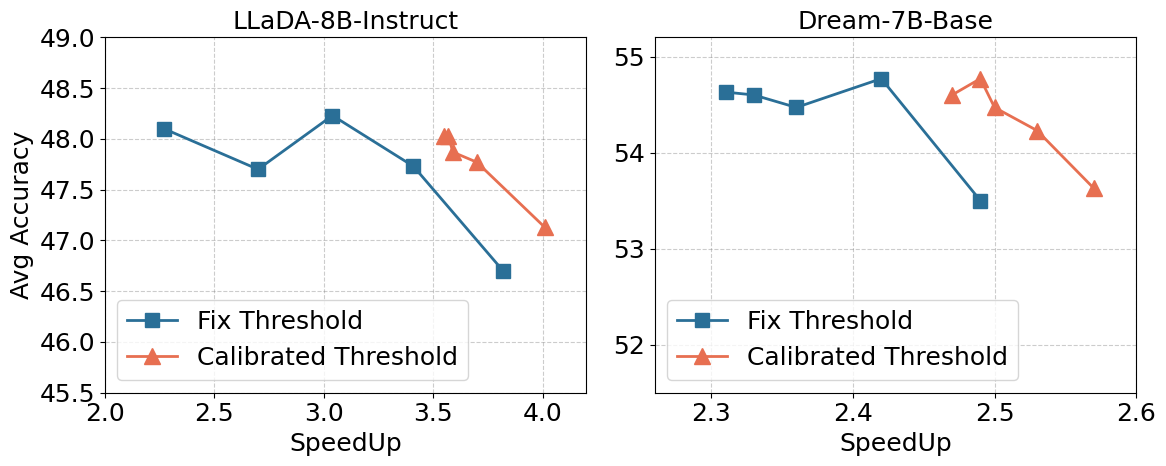

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Colors
# =========================
BLUE = "#2A6F97"
ORANGE = "#E76F51"

# =========================
# Font (ACL style)
# =========================
plt.rcParams.update({
    "font.size": 18,
})

# =========================
# Data (0.7 removed)
# =========================

# LLaDA-8B-Instruct
llada_fixed_acc = np.array([46.70, 47.73, 48.23, 47.70, 48.10])
llada_fixed_spd = np.array([3.82, 3.41, 3.04, 2.70, 2.27])

llada_cal_acc = np.array([47.13, 47.77, 47.87, 48.03, 48.03])
llada_cal_spd = np.array([4.01, 3.70, 3.59, 3.57, 3.55])

# Dream-7B-Base
dream_fixed_acc = np.array([53.50, 54.77, 54.47, 54.60, 54.63])
dream_fixed_spd = np.array([2.49, 2.42, 2.36, 2.33, 2.31])

dream_cal_acc = np.array([53.63, 54.23, 54.47, 54.77, 54.60])
dream_cal_spd = np.array([2.57, 2.53, 2.50, 2.49, 2.47])



# =========================
# Plot
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# =========================
# LLaDA
# =========================
ax = axes[0]

ax.plot(
    llada_fixed_spd, llada_fixed_acc,
    color=BLUE,
    marker="s",        # square
    markersize=10,     # bigger
    linewidth=2,
    label="Fix Threshold"
)

ax.plot(
    llada_cal_spd, llada_cal_acc,
    color=ORANGE,
    marker="^",        # triangle
    markersize=12,     # bigger
    linewidth=2,
    label="Calibrated Threshold"
)

ax.set_title("LLaDA-8B-Instruct", fontsize=18)
ax.set_xlabel("SpeedUp", fontsize=18)
ax.set_ylabel("Avg Accuracy", fontsize=18)

ax.grid(True, linestyle="--", color="gray", alpha=0.4)

ax.set_xlim(2.0, 4.2)
ax.set_ylim(45.5, 49.0)

ax.tick_params(labelsize=18)

ax.legend(fontsize=18)

# =========================
# Dream
# =========================
ax = axes[1]

ax.plot(
    dream_fixed_spd, dream_fixed_acc,
    color=BLUE,
    marker="s",
    markersize=10,
    linewidth=2,
    label="Fix Threshold"
)

ax.plot(
    dream_cal_spd, dream_cal_acc,
    color=ORANGE,
    marker="^",
    markersize=12,
    linewidth=2,
    label="Calibrated Threshold"
)

ax.set_title("Dream-7B-Base", fontsize=18)
ax.set_xlabel("SpeedUp", fontsize=18)

ax.grid(True, linestyle="--", color="gray", alpha=0.4)

ax.set_xlim(2.26, 2.6)
ax.set_ylim(51.5, 55.2)

ax.tick_params(labelsize=18)

ax.legend(fontsize=18)

# =========================
# layout
# =========================
plt.tight_layout()

# =========================
# save
# =========================
out_dir = Path("figures/pareto_frontier")
out_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(out_dir / "pareto_frontier.pdf", bbox_inches="tight", dpi=300)

plt.show()

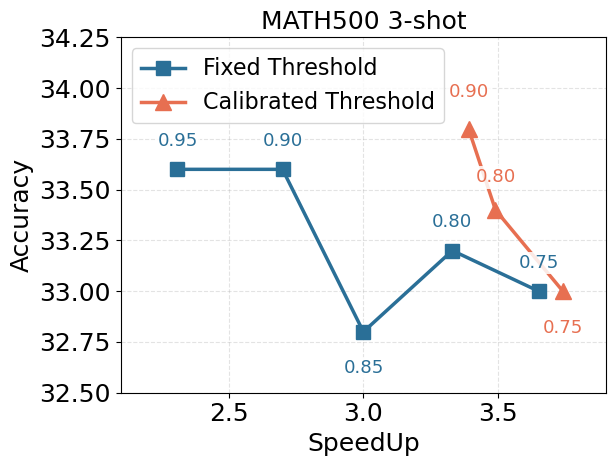

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Style
# =========================
BLUE = "#2A6F97"
ORANGE = "#E76F51"

plt.rcParams.update({
    "font.size": 18,
    "font.family": "DejaVu Sans",
})

# =========================
# Data: MATH500 3-shot
# =========================
thresholds = np.array([0.75, 0.80, 0.85, 0.90, 0.95])

fixed_acc = np.array([33.00, 33.20, 32.80, 33.60, 33.60])
fixed_speedup = np.array([3.65, 3.33, 3.00, 2.70, 2.31])

cal_acc = np.array([33.00, 33.40, 33.80, 33.80, 33.80])
cal_speedup = np.array([3.74, 3.49, 3.41, 3.39, 3.36])

# Keep 0.75, 0.80, 0.90 for calibrated threshold
cal_keep_mask = np.array([True, True, False, True, False])

cal_thr_plot = thresholds[cal_keep_mask]
cal_acc_plot = cal_acc[cal_keep_mask]
cal_speedup_plot = cal_speedup[cal_keep_mask]

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(6.5, 5.0))

ax.plot(
    fixed_speedup,
    fixed_acc,
    marker="s",
    markersize=10,
    linewidth=2.5,
    color=BLUE,
    label="Fixed Threshold",
)

ax.plot(
    cal_speedup_plot,
    cal_acc_plot,
    marker="^",
    markersize=11,
    linewidth=2.5,
    color=ORANGE,
    label="Calibrated Threshold",
)

# =========================
# Threshold annotations
# Use manual offsets to avoid overlapping with lines
# =========================
fixed_offsets = {
    0.75: (0.00,  0.14),
    0.80: (0.00,  0.14),
    0.85: (0.00, -0.18),
    0.90: (0.00,  0.14),
    0.95: (0.00,  0.14),
}

cal_offsets = {
    0.75: (0.00, -0.18),
    0.80: (0.00,  0.16),
    0.90: (0.00,  0.18),
}

for x, y, t in zip(fixed_speedup, fixed_acc, thresholds):
    dx, dy = fixed_offsets[float(t)]
    ax.text(
        x + dx,
        y + dy,
        f"{t:.2f}",
        fontsize=13,
        ha="center",
        va="center",
        color=BLUE,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5),
        zorder=10,
    )

for x, y, t in zip(cal_speedup_plot, cal_acc_plot, cal_thr_plot):
    dx, dy = cal_offsets[float(t)]
    ax.text(
        x + dx,
        y + dy,
        f"{t:.2f}",
        fontsize=13,
        ha="center",
        va="center",
        color=ORANGE,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5),
        zorder=10,
    )

# =========================
# Axis
# =========================
ax.set_xlabel("SpeedUp", fontsize=18)
ax.set_ylabel("Accuracy", fontsize=18)
ax.set_title("MATH500 3-shot", fontsize=18)

ax.tick_params(axis="both", labelsize=18)
ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)
ax.legend(fontsize=16, frameon=True)

ax.set_xlim(2.1, 3.9)
ax.set_ylim(32.5, 34.25)

plt.tight_layout()

# =========================
# Save
# =========================
out_dir = Path("figures/fewshot_pareto")
out_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(out_dir / "math500_3shot_pareto.pdf", bbox_inches="tight", dpi=300)
plt.savefig(out_dir / "math500_3shot_pareto.png", bbox_inches="tight", dpi=300)

plt.show()

/var/folders/nn/0bc1hht57p33htpp1ll490zr0000gp/T/ipykernel_3021/3184063795.py:291: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


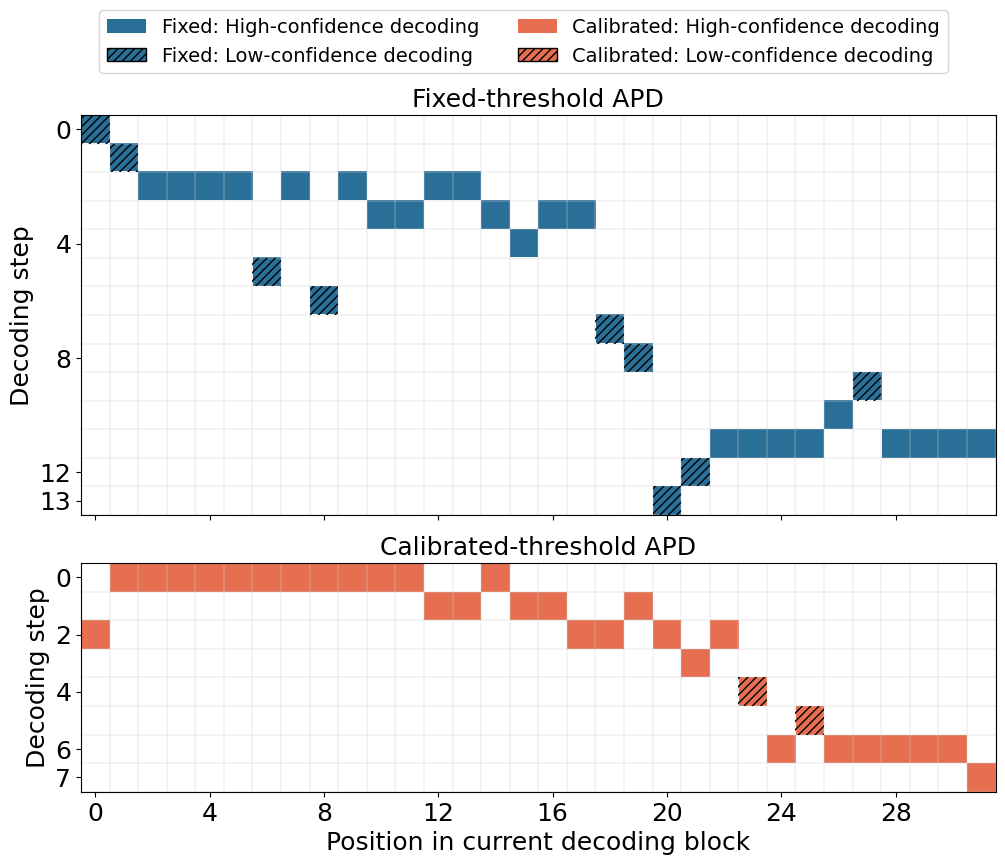

[INFO] Fixed block range: 101-132
[INFO] Calibrated block range: 70-101
[INFO] Fixed steps: 14
[INFO] Calibrated steps: 8


In [97]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch, Rectangle
from pathlib import Path


# =========================
# Config
# =========================
fixed_log_file = "logs/gsm8k_adaptive_parallel_len256_block32_thr0.90.log"
cal_log_file = "./logs/gsm8k_dynamic_from_global_v2_c99.5_mincount200_minaccepted100_len256_block32_maxthr0.90_minthr0.05.log"

sample_idx = 1
block_id = 1
block_size = 32

out_dir = Path("figures/decoding_path")
out_name = "decoding_path_grid.pdf"


# =========================
# Style
# =========================
plt.rcParams.update({
    "font.size": 18,
    "font.family": "DejaVu Sans",
    "hatch.linewidth": 1.0,
})

BLUE = "#2A6F97"
ORANGE = "#E76F51"
WHITE = "#FFFFFF"
GRID = "#D0D0D0"


# =========================
# Load selected_records from log
# =========================
def extract_json_array(text):
    start = text.find("[")
    if start == -1:
        raise ValueError("No JSON array found in log.")

    depth = 0
    for i in range(start, len(text)):
        if text[i] == "[":
            depth += 1
        elif text[i] == "]":
            depth -= 1
            if depth == 0:
                return text[start:i + 1]

    raise ValueError("JSON array not closed.")


def load_selected_records(log_file, sample_idx=0):
    with open(log_file, "r", encoding="utf-8") as f:
        text = f.read()

    arrays = []

    for line in text.splitlines():
        if "[" in line and "]" in line and ("step" in line or "selected" in line):
            try:
                arr_text = extract_json_array(line)
                arr = json.loads(arr_text)
                if isinstance(arr, list) and len(arr) > 0 and isinstance(arr[0], dict):
                    arrays.append(arr)
            except Exception:
                pass

    if len(arrays) == 0:
        arr_text = extract_json_array(text)
        arr = json.loads(arr_text)
        arrays.append(arr)

    if sample_idx >= len(arrays):
        raise IndexError(
            f"sample_idx={sample_idx} out of range. Found only {len(arrays)} arrays in {log_file}."
        )

    return arrays[sample_idx]


# =========================
# Build decoding grid
# =========================
def build_decoding_grid_from_selected_records(
    log_file,
    sample_idx,
    block_id,
    block_size,
):
    records = load_selected_records(log_file, sample_idx)
    records = [r for r in records if int(r.get("block", -1)) == block_id]

    if len(records) == 0:
        raise ValueError(f"No records found for block_id={block_id} in {log_file}")

    positions = [int(r["position"]) for r in records]

    # Align current block to local position 0
    block_start = min(positions)
    block_end = block_start + block_size

    records = [
        r for r in records
        if block_start <= int(r["position"]) < block_end
    ]

    steps = sorted(set(int(r["step"]) for r in records))
    min_step = min(steps)
    max_step = max(steps)

    num_steps = max_step - min_step + 1
    grid = np.zeros((num_steps, block_size), dtype=int)

    step_to_items = {}
    for r in records:
        step = int(r["step"])
        pos = int(r["position"])
        strategy = str(r.get("strategy", "")).lower()

        local_step = step - min_step
        local_pos = pos - block_start

        if 0 <= local_pos < block_size:
            step_to_items.setdefault(local_step, []).append((local_pos, strategy, r))

    for local_step, items in step_to_items.items():
        for local_pos, strategy, _ in items:
            # 1 = parallel decoding
            # 2 = single-token decoding
            if strategy == "single":
                grid[local_step, local_pos] = 2
            else:
                grid[local_step, local_pos] = 1

    return grid, block_start, block_end, records


# =========================
# Plot helper
# =========================
def plot_one_grid(ax, grid, title, color):
    """
    grid value:
        0 = not committed
        1 = parallel decoding
        2 = single-token decoding
    """
    base_grid = (grid > 0).astype(int)

    cmap = ListedColormap([WHITE, color])
    norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

    ax.imshow(
        base_grid,
        aspect="equal",
        interpolation="nearest",
        cmap=cmap,
        norm=norm,
        origin="upper",
    )

    num_steps, num_cols = grid.shape

    # cell grid lines
    ax.set_xticks(np.arange(-0.5, num_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, num_steps, 1), minor=True)
    ax.grid(which="minor", color=GRID, linewidth=0.35)
    ax.tick_params(which="minor", bottom=False, left=False)

    # x ticks
    ax.set_xticks(np.arange(0, num_cols, 4))
    ax.set_xticklabels(np.arange(0, num_cols, 4))

    # y ticks
    if num_steps <= 12:
        y_interval = 2
    elif num_steps <= 24:
        y_interval = 4
    else:
        y_interval = 8

    yticks = np.arange(0, num_steps, y_interval)
    if len(yticks) == 0 or yticks[-1] != num_steps - 1:
        yticks = np.append(yticks, num_steps - 1)

    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks)

    ax.set_ylabel("Decoding step")
    ax.set_title(title, fontsize=18)

    # hatch single-token decoding cells
    single_rows, single_cols = np.where(grid == 2)
    for row, col in zip(single_rows, single_cols):
        rect = Rectangle(
            (col - 0.5, row - 0.5),
            1.0,
            1.0,
            facecolor="none",
            edgecolor="black",
            hatch="////",
            linewidth=0.0,
            zorder=5,
        )
        ax.add_patch(rect)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


# =========================
# Build grids
# =========================
fixed_grid, fixed_start, fixed_end, fixed_records = build_decoding_grid_from_selected_records(
    fixed_log_file,
    sample_idx,
    block_id,
    block_size,
)

cal_grid, cal_start, cal_end, cal_records = build_decoding_grid_from_selected_records(
    cal_log_file,
    sample_idx,
    block_id,
    block_size,
)

fixed_steps = fixed_grid.shape[0]
cal_steps = cal_grid.shape[0]


# =========================
# Plot
# =========================
cell_size = 0.30
fig_width = block_size * cell_size + 2.2
fig_height = (fixed_steps + cal_steps) * cell_size + 2.2

fig, axes = plt.subplots(
    2, 1,
    figsize=(fig_width, fig_height),
    sharex=True,
    gridspec_kw={
        "height_ratios": [fixed_steps, cal_steps],
        "hspace": 0.15,   # smaller space between the two plots
    },
)

plot_one_grid(
    axes[0],
    fixed_grid,
    "Fixed-threshold APD",
    BLUE,
)

plot_one_grid(
    axes[1],
    cal_grid,
    "Calibrated-threshold APD",
    ORANGE,
)

axes[1].set_xlabel("Position in current decoding block")


# =========================
# Legend: 4 entries
# =========================
legend_items = [
    Patch(facecolor=BLUE, edgecolor="none", label="Fixed: High-confidence decoding"),
    Patch(facecolor=BLUE, edgecolor="black", hatch="////", label="Fixed: Low-confidence decoding"),
    Patch(facecolor=ORANGE, edgecolor="none", label="Calibrated: High-confidence decoding"),
    Patch(facecolor=ORANGE, edgecolor="black", hatch="////", label="Calibrated: Low-confidence decoding"),
]

fig.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=True,
    fontsize=14,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])


# =========================
# Save
# =========================
out_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(out_dir / out_name, bbox_inches="tight", dpi=300)
plt.savefig(out_dir / out_name.replace(".pdf", ".png"), bbox_inches="tight", dpi=300)

plt.show()

print(f"[INFO] Fixed block range: {fixed_start}-{fixed_end - 1}")
print(f"[INFO] Calibrated block range: {cal_start}-{cal_end - 1}")
print(f"[INFO] Fixed steps: {fixed_steps}")
print(f"[INFO] Calibrated steps: {cal_steps}")

生成考虑所有step的置信度阈值

In [24]:
import json
import numpy as np
import pandas as pd
from pathlib import Path


# =========================
# Config
# =========================
target_precision = 0.995

# token 总出现次数至少多少，才尝试计算 token-specific threshold
min_count = 200

# 在某个 threshold 以上，accepted samples 至少多少，才认为这个 threshold 有统计意义
min_accepted = 100

threshold_start = 1.0
threshold_end = 0.01
threshold_step = 0.005

confidence_col = "confidence"
token_col = "token_id"

# 兼容两种列名
if "final_consistent" in all_df.columns:
    label_col = "final_consistent"
elif "is_final_consistent" in all_df.columns:
    label_col = "is_final_consistent"
else:
    raise ValueError("Cannot find final_consistent / is_final_consistent column.")

out_dir = Path("token_threshold_on_trainset")
task_name = "gsm8k_train"
out_dir.mkdir(parents=True, exist_ok=True)


json_path = out_dir / (
    f"{task_name}_token_threshold_grid_p{float(target_precision * 100):.1f}"
    f"_mincount{min_count}_minaccepted{min_accepted}.json"
)

csv_path = out_dir / (
    f"{task_name}_token_threshold_grid_p{float(target_precision * 100):.1f}"
    f"_mincount{min_count}_minaccepted{min_accepted}.csv"
)
# =========================


def build_grid_thresholds(
    all_df,
    target_precision=0.95,
    min_count=100,
    min_accepted=50,
    threshold_start=1.0,
    threshold_end=0.05,
    threshold_step=0.05,
    token_col="token_id",
    confidence_col="confidence",
    label_col="final_consistent",
):
    df = all_df[[token_col, confidence_col, label_col]].copy()

    df[token_col] = df[token_col].astype(int)
    df[confidence_col] = df[confidence_col].astype(float)
    df[label_col] = df[label_col].astype(bool).astype(int)

    # 过滤合法 confidence
    df = df[np.isfinite(df[confidence_col])]
    df = df[(df[confidence_col] >= 0.0) & (df[confidence_col] <= 1.0)].copy()

    # token 总出现次数
    total_counts = df.groupby(token_col).size().rename("total_count")
    eligible_tokens = set(total_counts[total_counts >= min_count].index.tolist())

    # 低频 token 不参与、不保存
    df = df[df[token_col].isin(eligible_tokens)].copy()

    print(f"[INFO] Total unique tokens: {total_counts.shape[0]}")
    print(f"[INFO] Eligible tokens with count >= {min_count}: {len(eligible_tokens)}")
    print(f"[INFO] Records after filtering low-count tokens: {len(df)}")
    print(f"[INFO] Required accepted samples per threshold >= {min_accepted}")
    print(f"[INFO] Required final-consistency rate >= {target_precision}")

    thresholds = np.round(
        np.arange(threshold_start, threshold_end - 1e-9, -threshold_step),
        6,
    )

    # chosen[token_id] = 最低可行阈值的信息
    chosen = {}

    # 从高到低扫；每次满足就覆盖，因此最后留下的是“最低满足阈值”
    for tau in thresholds:
        sub = df[df[confidence_col] >= tau]

        if sub.empty:
            continue

        stats = (
            sub.groupby(token_col)
            .agg(
                coverage=(label_col, "size"),
                success=(label_col, "sum"),
            )
            .reset_index()
        )

        stats["precision"] = stats["success"] / stats["coverage"]

        # 三重条件：
        # 1. token 总出现次数 >= min_count 已经在 eligible_tokens 里保证
        # 2. accepted samples at threshold >= min_accepted
        # 3. final-consistency rate >= target_precision
        ok = stats[
            (stats["coverage"] >= min_accepted)
            & (stats["precision"] >= target_precision)
        ]

        for _, row in ok.iterrows():
            tid = int(row[token_col])

            chosen[tid] = {
                "token_id": tid,
                "threshold": float(tau),
                "coverage": int(row["coverage"]),
                "success": int(row["success"]),
                "precision": float(row["precision"]),
            }

    # 整理输出
    rows = []
    for tid in sorted(eligible_tokens):
        if tid in chosen:
            item = chosen[tid]
            item["status"] = "ok"
        else:
            item = {
                "token_id": int(tid),
                "threshold": np.nan,
                "coverage": 0,
                "success": 0,
                "precision": np.nan,
                "status": "fallback_no_valid_threshold",
            }

        item["total_count"] = int(total_counts.loc[tid])
        rows.append(item)

    result_df = pd.DataFrame(rows)

    # 只把成功计算出阈值的 token 写入 JSON
    ok_df = result_df[result_df["status"] == "ok"].copy()

    threshold_dict = {
        str(int(row["token_id"])): float(row["threshold"])
        for _, row in ok_df.iterrows()
    }

    return threshold_dict, result_df


threshold_dict, threshold_stats = build_grid_thresholds(
    all_df=all_df,
    target_precision=target_precision,
    min_count=min_count,
    min_accepted=min_accepted,
    threshold_start=threshold_start,
    threshold_end=threshold_end,
    threshold_step=threshold_step,
    token_col=token_col,
    confidence_col=confidence_col,
    label_col=label_col,
)

# 保存 JSON
with json_path.open("w", encoding="utf-8") as f:
    json.dump(threshold_dict, f, indent=2, ensure_ascii=False)

# 保存 CSV
threshold_stats.to_csv(csv_path, index=False)

print(f"[SAVED] {json_path}")
print(f"[SAVED] {csv_path}")
print()

num_total_unique = all_df[token_col].nunique()
num_eligible = (threshold_stats["total_count"] >= min_count).sum()
num_success = (threshold_stats["status"] == "ok").sum()
num_no_valid = (threshold_stats["status"] == "fallback_no_valid_threshold").sum()

print("====== Threshold Statistics ======")
print(f"Total unique tokens in log: {num_total_unique}")
print(f"Tokens with count >= {min_count}: {num_eligible}")
print(f"Tokens successfully assigned thresholds: {num_success}")
print(f"Eligible tokens without valid threshold: {num_no_valid}")
print(f"Tokens saved to JSON: {len(threshold_dict)}")
print("==================================")

display(
    threshold_stats[threshold_stats["status"] == "ok"]
    .sort_values("threshold", ascending=True)
    .head(10)
)

[INFO] Total unique tokens: 14683
[INFO] Eligible tokens with count >= 200: 4358
[INFO] Records after filtering low-count tokens: 30969508
[INFO] Required accepted samples per threshold >= 100
[INFO] Required final-consistency rate >= 0.995
[SAVED] token_threshold_on_trainset/gsm8k_train_token_threshold_grid_p99.5_mincount200_minaccepted100.json
[SAVED] token_threshold_on_trainset/gsm8k_train_token_threshold_grid_p99.5_mincount200_minaccepted100.csv

====== Threshold Statistics ======
Total unique tokens in log: 14683
Tokens with count >= 200: 4358
Tokens successfully assigned thresholds: 3727
Eligible tokens without valid threshold: 631
Tokens saved to JSON: 3727


,token_id,threshold,coverage,success,precision,status,total_count
4194,99384,0.190,228,227,0.995614,ok,237
763,3167,0.255,315,314,0.996825,ok,354
804,3362,0.275,286,285,0.996503,ok,375
2768,23776,0.280,170,170,1.000000,ok,220
2256,15265,0.285,206,205,0.995146,ok,228
3135,32769,0.290,225,225,1.000000,ok,267
3411,42051,0.300,163,163,1.000000,ok,214
1202,5904,0.300,182,182,1.000000,ok,211
4073,84465,0.310,211,210,0.995261,ok,226
2690,22456,0.310,208,207,0.995192,ok,221
